# extended hard tests

In [1]:

from continuous_to_continuous import *
import time


c:\Users\User\anaconda3\envs\lior_XAI\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:

# 1. Setup & Data
X, X_hidden, y, ground_truth = generate_synthetic_data_with_complex_features(
    num_inputs = 3000, 
    num_samples = 50000, 
    num_contributing_features = (5, 15), 
    num_hidden_features = (100, 200), 
    weight_range = (-3.0, 3.0), 
    shift_range = (-2.0, 2.0),
    num_interactions = (10, 20), 
    num_poly_features = (3, 6),      
    num_v_shaped_features = (3, 6),   
    interaction_weight_range = (-3.0, 3.0), 
    noise_std = 0.05, 
    hidden_in_linear = True,
    hidden_in_interactions = True,
    hidden_in_nonlinear = True,
    input_range = (-5.0, 5.0),
    missing_pct = 0.1,          # 10% of the data will be missing (NaN)
    error_pct = 0.1             # 10% of the data will be corrupted
    )



# Split data here so both OLS and XGBoost train on the exact same subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=None)

# ground_truth

--- Generative Model Info ---
Linear: 13 | Interactions: 11 | Poly: 3 | V-shaped: 3

--- True Equation ---
y = 1.1652 + (0.0472 * Feature_2597 + 0.3532) + (-2.4644 * Feature_2575 + 1.1934) + (2.7627 * Feature_218 + 1.5363) + (-2.6926 * Feature_635 + -0.8419) + (2.7878 * Feature_600 + 0.4795) + (-2.7222 * Feature_578 + -1.5128) + (0.6033 * Feature_1423 + -0.8717) + (1.2180 * Feature_797 + 1.0742) + (2.4482 * Feature_1097 + 1.7705) + (1.2715 * Feature_1413 + 0.0361) + (2.4450 * Feature_2347 + 0.8656) + (1.2528 * Feature_1248 + -1.2075) + (0.6687 * Feature_1542 + -1.0365) + (2.2119 * Feature_959 * Feature_1250 + -0.3598) + (-2.1244 * Feature_1856 * Feature_2295 + -1.2946) + (1.9218 * Feature_1140 * Feature_2382 + 0.1756) + (-2.0469 * Feature_362 * Feature_1101 + -1.9935) + (1.3121 * Feature_1515 * Feature_2412 + -0.1900) + (1.2251 * Feature_458 * Feature_1689 + -0.3697) + (2.7266 * Feature_1384 * Feature_2904 + 1.0824) + (2.4670 * Feature_680 * Feature_1998 + -1.5698) + (2.4154 * Feature_

In [3]:

# # 1. Setup & Data
# X, hidden_features, y, feature_names, hidden_feature_names, true_linear_weights, true_interaction_weights = generate_synthetic_data_with_hidden_features(
#     num_inputs = 3000, 
#     num_samples = 50000, 
#     num_contributing_features = (5, 15), 
#     num_hidden_features = (100, 200), 
#     input_range = (-10.0, 10.0),
#     weight_range = (-7, 7), 
#     num_interactions = (10, 20), 
#     interaction_weight_range = (-5, 5), 
#     noise_std = 0.05, 
#     hidden_in_linear = True,           # Should hidden features have a linear impact?
#     hidden_in_interactions = True,     # Should hidden features be part of interactions?
#     missing_pct = 0.1,                 # 10% of the data will be missing (NaN)
#     error_pct = 0.1,                   # 10% of the data will be corrupted
#     )

# # Split data here so both OLS and XGBoost train on the exact same subsets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=None)


## Spearman rank correlation trail

In [4]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

def calculate_spearman_with_pvalues(X, Y, nan_strategy="impute_mean")-> pd.DataFrame:
    """
    Calculates the Spearman rank correlation coefficients and p-values
    between all columns of X and Y, outputting a single flat DataFrame.
    
    Parameters:
    X (pd.DataFrame): First DataFrame of shape (n_samples, n_features_X)
    Y (pd.DataFrame): Second DataFrame of shape (n_samples, n_features_Y)
    nan_strategy (str): Strategy to handle NaN values. Options:
                        - "drop": Drop any rows with NaN values in either X or Y.
                        - "impute_mean": Impute NaN values with the mean of each column.
    
    Returns:
    pd.DataFrame: A flat DataFrame with columns:
                  ['X_feature', 'Y_feature', 'correlation', 'p_value']
    """
    
    # 1. Handle Missing Values
    if X.isna().sum().sum() > 0:
        print(f"Warning: {X.isna().sum().sum()} missing values detected in X.")
        
        if nan_strategy == "drop":
            valid_rows_mask = ~X.isna().any(axis=1)
            X = X[valid_rows_mask].copy()
            Y = Y[valid_rows_mask].copy() if isinstance(Y, np.ndarray) else Y[valid_rows_mask].copy()
            print(f"Dropped {len(X) - len(X)} rows containing NaNs.")
            
        elif nan_strategy == "impute_mean":
            X = X.fillna(X.mean())
            Y = Y.fillna(Y.mean()) if isinstance(Y, pd.DataFrame) else pd.DataFrame(Y).fillna(pd.DataFrame(Y).mean())
            print("Imputed missing values with column means.")
            
        else:
            raise ValueError("nan_strategy must be either 'drop' or 'impute_mean'")
    else:
        X = pd.DataFrame(X)
        Y = pd.DataFrame(Y)
    
    if X.shape[0] != Y.shape[0]:
        raise ValueError("DataFrames X and Y must have the same number of rows.")
    
    p = X.shape[1]
    q = Y.shape[0]
    
    # Calculate using scipy
    corr_matrix, p_matrix = spearmanr(X, Y)
    
    # Handle the case where both X and Y have exactly 1 column 
    # (scipy's spearmanr returns scalars instead of matrices in this case)
    if p == 1 and q == 1:
        corr_data = np.array([[corr_matrix]])
        p_data = np.array([[p_matrix]])
    else:
        # Extract the cross-correlation block (rows of X, columns of Y)
        corr_data = corr_matrix[:p, p:]
        p_data = p_matrix[:p, p:]
        
    # Convert cross-correlation blocks to DataFrames
    corr_df = pd.DataFrame(corr_data, index=X.columns, columns=Y.columns)
    p_val_df = pd.DataFrame(p_data, index=X.columns, columns=Y.columns)
    
    # Name the index and columns to ensure clean labels after flattening
    corr_df.index.name = 'X_feature'
    corr_df.columns.name = 'Y_feature'
    p_val_df.index.name = 'X_feature'
    p_val_df.columns.name = 'Y_feature'
    
    # Reshape from wide to long format using .stack()
    corr_flat = corr_df.stack()
    pval_flat = p_val_df.stack()
    
    # Combine into a single DataFrame and reset the index
    results_df = pd.DataFrame({
        'correlation': corr_flat,
        'p_value': pval_flat
    }).reset_index()
    
    return results_df

In [5]:

Spearman_correlation = calculate_spearman_with_pvalues(X_train, y_train)
Spearman_correlation.sort_values(by='p_value', ascending=True, inplace=True)
Spearman_correlation.set_index('X_feature', inplace=True)
Spearman_correlation.drop(columns='Y_feature', inplace=True)
# Spearman_correlation.sort_values(by='correlation', ascending=False, inplace=False)
Spearman_correlation


Imputed missing values with column means.


,correlation,p_value
X_feature,,
Feature_600,0.260704,0.000000
Feature_635,-0.259116,0.000000
Feature_218,0.269214,0.000000
Feature_2575,-0.233023,0.000000
Feature_578,-0.252833,0.000000
...,...,...
Feature_1448,-0.000010,0.998480
Feature_3,-0.000008,0.998661
Feature_16,0.000008,0.998708


In [6]:

p = 0.05
significant_features = Spearman_correlation[Spearman_correlation['p_value'] < p/len(Spearman_correlation)].index.tolist()
print(f"Significant features at p < {p}: {significant_features}")

# metrics = evaluate_feature_discovery(significant_features,true_linear_weights, true_interaction_weights)
metrics = evaluate_feature_discovery(
    detected_features=significant_features,
    ground_truth=ground_truth,
    evaluated_features=None,
)


Significant features at p < 0.05: ['Feature_600', 'Feature_635', 'Feature_218', 'Feature_2575', 'Feature_578', 'Feature_1097', 'Feature_2347', 'Feature_1413', 'Feature_1248', 'Feature_797', 'Feature_1542', 'Feature_1423']
        FEATURE DISCOVERY EVALUATION             
Overall Precision : 1.0000 (12/12)
Overall Recall    : 0.3000 (12/40)
Overall F1-Score  : 0.4615
False Positives   : []

---------------- Category Breakdown --------------

[LINEAR]
  True Features     : ['Feature_1097', 'Feature_1248', 'Feature_1413', 'Feature_1423', 'Feature_1542', 'Feature_218', 'Feature_2347', 'Feature_2575', 'Feature_2597', 'Feature_578', 'Feature_600', 'Feature_635', 'Feature_797']
  Detected          : ['Feature_1097', 'Feature_1248', 'Feature_1413', 'Feature_1423', 'Feature_1542', 'Feature_218', 'Feature_2347', 'Feature_2575', 'Feature_578', 'Feature_600', 'Feature_635', 'Feature_797']
  Missed            : ['Feature_2597']
  Recall            : 0.9231 (12/13)

[POLY]
  True Features     : ['Fe

## Maximal Information Coefficient (MIC) trail

In [7]:

from minepy import MINE
from minepy import pstats, cstats

# mine = MINE()
# mine.compute_score(X_train.iloc[:, 2640], y_train)
# mic_score = mine.mic()
# print(f"MIC Score: {mic_score}")

# x = X_train.iloc[0:100, 0:10].to_numpy().T
# X_train.iloc[0:100, 0:10].shape
# print("X_train subset shape:", x.shape)
# # transpose x, columns to rows and rows to columns
# # x.reshape(-1, 1).shape

# mic_p, tic_p =  pstats(x, alpha=9, c=5, est="mic_e")
# print("normalized TIC_e (X):")
# print(tic_p)
# print("MIC_e (X vs. Y):")
# print(mic_p)
# mic_p.shape
# tic_p.shape

# y = y_train.iloc[0:100].to_numpy().reshape(-1, 1).T
# print("y shape:", y.shape)
# np.corrcoef(x, y)
# np.around(np.corrcoef(x, y)[0, 1], 1)

i = 0
print(X_train.iloc[0:, i])

mine = MINE()

# Select the first column as a Series to get a 1D numpy array
x = X_train.iloc[0:, i].to_numpy()
print("X_train subset shape:", x.shape)  # Expected: (1000,)

# Get the target values as a 1D numpy array by flattening it
y = y_train.iloc[0:].to_numpy().flatten()
print("y shape:", y.shape)  # Expected: (1000,)

corrcoef = np.corrcoef(x, y)
print("Correlation Coefficient:")
print(corrcoef)

# Compute score and get MIC
mine.compute_score(x, y)
mic_score = mine.mic()
print(f"MIC Score: {mic_score}")


41933    0.180857
17697    0.380725
11921    0.937660
5345    -0.195805
36036   -0.981564
           ...   
2677    -0.225893
6634     0.518216
3558     0.272175
48655   -0.567101
33463    0.479965
Name: Feature_0, Length: 40000, dtype: float64
X_train subset shape: (40000,)
y shape: (40000,)
Correlation Coefficient:
[[nan nan]
 [nan  1.]]
MIC Score: 0.03575748833621089


In [8]:
import numpy as np
from minepy import MINE

i = 0
print(X_train.iloc[:, i])  # Simplified from iloc[0:, i]

# 1. Initialize MINE with optimized speed parameters:
# - est="mic_e": Uses the faster equipartitioning estimator instead of "mic_approx"
# - alpha=0.5: Restricts the maximum grid size, speeding up computation
# - c=5: Reduces the density of grid clumps to further minimize calculations
mine = MINE(alpha=0.5, c=5, est="mic_e")

# Select the first column as a Series to get a 1D numpy array
x = X_train.iloc[:, i].to_numpy()
print("X_train subset shape:", x.shape)

# Get the target values as a 1D numpy array by flattening it
y = y_train.iloc[:].to_numpy().flatten()
print("y shape:", y.shape)

corrcoef = np.corrcoef(x, y)
print("Correlation Coefficient:")
print(corrcoef)

# Compute score and get MIC
mine.compute_score(x, y)
mic_score = mine.mic()
print(f"MIC Score: {mic_score}")

41933    0.180857
17697    0.380725
11921    0.937660
5345    -0.195805
36036   -0.981564
           ...   
2677    -0.225893
6634     0.518216
3558     0.272175
48655   -0.567101
33463    0.479965
Name: Feature_0, Length: 40000, dtype: float64
X_train subset shape: (40000,)
y shape: (40000,)
Correlation Coefficient:
[[nan nan]
 [nan  1.]]
MIC Score: 0.0023325169688984512


In [9]:
import pandas as pd
from minepy import cstats

def calculate_mic_scores_cstats(X, Y, alpha=0.5, c=5, est="mic_e", nan_strategy="impute_mean") -> pd.DataFrame:
    """
    Calculates the Maximal Information Coefficient (MIC) between all columns 
    of DataFrame X and DataFrame Y using minepy's fast cstats function.
    
    Parameters:
    X (pd.DataFrame): First DataFrame of shape (n_samples, n_features_X)
    Y (pd.DataFrame): Second DataFrame of shape (n_samples, n_features_Y)
    alpha (float): Parameter controlling maximum grid size (default: 0.5)
    c (float): Parameter controlling grid clump density (default: 5)
    est (str): Estimator type, e.g., "mic_e" or "mic_approx" (default: "mic_e")
    nan_strategy (str): Strategy to handle NaN values. Options:
                        - "drop": Drop any rows with NaN values in either X or Y.
                        - "impute_mean": Impute NaN values with the mean of each column.
    
    Returns:
    pd.DataFrame: A flat DataFrame with columns:
                  ['X_feature', 'Y_feature', 'mic_score', 'tic_score']
    """
    # 1. Handle Missing Values
    if X.isna().sum().sum() > 0:
        print(f"Warning: {X.isna().sum().sum()} missing values detected in X.")
        
        if nan_strategy == "drop":
            valid_rows_mask = ~X.isna().any(axis=1)
            X = X[valid_rows_mask].copy()
            Y = Y[valid_rows_mask].copy() if isinstance(Y, np.ndarray) else Y[valid_rows_mask].copy()
            print(f"Dropped {len(X) - len(X)} rows containing NaNs.")
            
        elif nan_strategy == "impute_mean":
            X = X.fillna(X.mean())
            Y = Y.fillna(Y.mean()) if isinstance(Y, pd.DataFrame) else pd.DataFrame(Y).fillna(pd.DataFrame(Y).mean())
            print("Imputed missing values with column means.")
            
        else:
            raise ValueError("nan_strategy must be either 'drop' or 'impute_mean'")
    else:
        X = pd.DataFrame(X)
        Y = pd.DataFrame(Y)
    
    if X.shape[0] != Y.shape[0]:
        raise ValueError("DataFrames X and Y must have the same number of rows.")
    
    # Transpose the numpy arrays because cstats expects variables as rows, samples as columns
    X_arr = X.to_numpy().T
    Y_arr = Y.to_numpy().T
    
    # cstats returns two matrices: MIC and TIC
    mic_matrix, tic_matrix = cstats(X_arr, Y_arr, alpha=alpha, c=c, est=est)
    
    # Wrap matrices back into temporary DataFrames matching original feature names
    mic_df = pd.DataFrame(mic_matrix, index=X.columns, columns=Y.columns)
    tic_df = pd.DataFrame(tic_matrix, index=X.columns, columns=Y.columns)
    
    # Label the index and columns for flattening
    mic_df.index.name = 'X_feature'
    mic_df.columns.name = 'Y_feature'
    tic_df.index.name = 'X_feature'
    tic_df.columns.name = 'Y_feature'
    
    # Flatten the matrices using .stack() and combine
    flat_results = pd.DataFrame({
        'mic_score': mic_df.stack(),
        'tic_score': tic_df.stack()
    }).reset_index()
    
    return flat_results

In [10]:

mic_scores = calculate_mic_scores_cstats(X_train, y_train)
mic_scores.sort_values(by='mic_score', ascending=False, inplace=True)
# mic_scores.sort_values(by='tic_score', ascending=False, inplace=True)
mic_scores.set_index('X_feature', inplace=True)
mic_scores.drop(columns='Y_feature', inplace=True)
mic_scores


Imputed missing values with column means.


,mic_score,tic_score
X_feature,,
Feature_218,0.041038,0.028429
Feature_635,0.039368,0.026360
Feature_600,0.038959,0.026640
Feature_578,0.036709,0.024930
Feature_1097,0.031409,0.022031
...,...,...
Feature_1186,0.001944,0.001000
Feature_2197,0.001944,0.000988
Feature_1302,0.001934,0.000967


In [11]:

C = 1

mic_scores['mic_score'].mean()
mic_scores['mic_score'].std()

significant_features = mic_scores[mic_scores['mic_score'] > C * mic_scores['mic_score'].mean() + C * mic_scores['mic_score'].std()]
print(f"Significant features with MIC > mean + {C}*std: {significant_features.index.tolist()}")

# metrics = evaluate_feature_discovery(significant_features.index.tolist(),true_linear_weights, true_interaction_weights)
metrics = evaluate_feature_discovery(
    detected_features=significant_features.index.tolist(),
    ground_truth=ground_truth,
    evaluated_features=None,
)


Significant features with MIC > mean + 1*std: ['Feature_218', 'Feature_635', 'Feature_600', 'Feature_578', 'Feature_1097', 'Feature_2575', 'Feature_2347', 'Feature_1248', 'Feature_1413', 'Feature_797', 'Feature_311', 'Feature_1542', 'Feature_1423']
        FEATURE DISCOVERY EVALUATION             
Overall Precision : 1.0000 (13/13)
Overall Recall    : 0.3250 (13/40)
Overall F1-Score  : 0.4906
False Positives   : []

---------------- Category Breakdown --------------

[LINEAR]
  True Features     : ['Feature_1097', 'Feature_1248', 'Feature_1413', 'Feature_1423', 'Feature_1542', 'Feature_218', 'Feature_2347', 'Feature_2575', 'Feature_2597', 'Feature_578', 'Feature_600', 'Feature_635', 'Feature_797']
  Detected          : ['Feature_1097', 'Feature_1248', 'Feature_1413', 'Feature_1423', 'Feature_1542', 'Feature_218', 'Feature_2347', 'Feature_2575', 'Feature_578', 'Feature_600', 'Feature_635', 'Feature_797']
  Missed            : ['Feature_2597']
  Recall            : 0.9231 (12/13)

[POLY]

In [12]:

C = 1.

mic_scores['tic_score'].mean()
mic_scores['tic_score'].std()

significant_features = mic_scores[mic_scores['tic_score'] > C * mic_scores['tic_score'].mean() + C * mic_scores['tic_score'].std()]
print(f"Significant features with TIC > mean + {C}*std: {significant_features.index.tolist()}")

# metrics = evaluate_feature_discovery(significant_features.index.tolist(),true_linear_weights, true_interaction_weights)
metrics = evaluate_feature_discovery(
    detected_features=significant_features.index.tolist(),
    ground_truth=ground_truth,
    evaluated_features=None,
)


Significant features with TIC > mean + 1.0*std: ['Feature_218', 'Feature_635', 'Feature_600', 'Feature_578', 'Feature_1097', 'Feature_2575', 'Feature_2347', 'Feature_1248', 'Feature_1413', 'Feature_797', 'Feature_311', 'Feature_1542', 'Feature_1423', 'Feature_768']
        FEATURE DISCOVERY EVALUATION             
Overall Precision : 1.0000 (14/14)
Overall Recall    : 0.3500 (14/40)
Overall F1-Score  : 0.5185
False Positives   : []

---------------- Category Breakdown --------------

[LINEAR]
  True Features     : ['Feature_1097', 'Feature_1248', 'Feature_1413', 'Feature_1423', 'Feature_1542', 'Feature_218', 'Feature_2347', 'Feature_2575', 'Feature_2597', 'Feature_578', 'Feature_600', 'Feature_635', 'Feature_797']
  Detected          : ['Feature_1097', 'Feature_1248', 'Feature_1413', 'Feature_1423', 'Feature_1542', 'Feature_218', 'Feature_2347', 'Feature_2575', 'Feature_578', 'Feature_600', 'Feature_635', 'Feature_797']
  Missed            : ['Feature_2597']
  Recall            : 0.923

In [13]:

# get a list of the union of the keys of true_linear_weights and true_interaction_weights
# all_keys = set(true_linear_weights.keys()) | set(true_interaction_weights.keys())
all_keys = (
    set(ground_truth["linear"].keys())
    | set(ground_truth["poly"].keys())
    | set(ground_truth["v_shaped"].keys())
    | {f for item in ground_truth["interactions"] for f in item["features"]}
)
all_visible_keys = {f for f in all_keys if not f.startswith("Hidden_")}
all_keys = all_visible_keys
all_keys

mic_scores[mic_scores.index.isin(all_keys)].mean()

print("Mean MIC score for true contributing features:", mic_scores[mic_scores.index.isin(all_keys)]['mic_score'].mean())
print("Mean MIC score for non-contributing features:", mic_scores[~mic_scores.index.isin(all_keys)]['mic_score'].mean())

print("Mean TIC score for true contributing features:", mic_scores[mic_scores.index.isin(all_keys)]['tic_score'].mean())
print("Mean TIC score for non-contributing features:", mic_scores[~mic_scores.index.isin(all_keys)]['tic_score'].mean())

mic_scores[mic_scores.index.isin(all_keys)].sort_values(by='mic_score', ascending=False)


Mean MIC score for true contributing features: 0.009118065134870458
Mean MIC score for non-contributing features: 0.002369729198994794
Mean TIC score for true contributing features: 0.005783041031612193
Mean TIC score for non-contributing features: 0.0010755417162186063


,mic_score,tic_score
X_feature,,
Feature_218,0.041038,0.028429
Feature_635,0.039368,0.026360
Feature_600,0.038959,0.026640
Feature_578,0.036709,0.024930
Feature_1097,0.031409,0.022031
Feature_2575,0.031265,0.021267
Feature_2347,0.030162,0.020433
Feature_1248,0.009897,0.006095
Feature_1413,0.009582,0.006255


## Distance Correlation ($dCor$) trail

In [14]:

import dcor

i = 1512
# Select the first column as a Series to get a 1D numpy array
x = X_train.iloc[0:, i].to_numpy()
print("X_train subset shape:", x.shape)  # Expected: (5000,)

# Get the target values as a 1D numpy array by flattening it
y = y_train.iloc[0:].to_numpy().flatten()
print("y shape:", y.shape)  # Expected: (5000,)

dcor_score = dcor.distance_correlation(x, y)
print(f"Distance Correlation: {dcor_score}")


X_train subset shape: (40000,)
y shape: (40000,)
Distance Correlation: nan


In [15]:
import pandas as pd
import numpy as np
import dcor

def calculate_dcor_with_pvalues(X, Y, method="t_test", num_resamples=199, random_state=None, nan_strategy="impute_mean") -> pd.DataFrame:
    """
    Calculates the Distance Correlation (dcor) and its corresponding p-value 
    between all columns of DataFrame X and DataFrame Y.
    
    Parameters:
    X (pd.DataFrame): First DataFrame of shape (n_samples, n_features_X)
    Y (pd.DataFrame): Second DataFrame of shape (n_samples, n_features_Y)
    method (str): 't_test' (default) for the fast, parametric Student's t-test,
                  or 'permutation' for the slower, exact permutation test.
    num_resamples (int): Number of permutations to run (only used if method='permutation').
    random_state (int or np.random.RandomState): Seed for the permutation test.
    nan_strategy (str): Strategy to handle NaN values. Options:
                        - "drop": Drop any rows with NaN values in either X or Y.
                        - "impute_mean": Impute NaN values with the mean of each column.
    
    Returns:
    pd.DataFrame: A flat DataFrame with columns:
                  ['X_feature', 'Y_feature', 'dcor_score', 'p_value']
    """
    # 1. Handle Missing Values
    if X.isna().sum().sum() > 0:
        print(f"Warning: {X.isna().sum().sum()} missing values detected in X.")
        
        if nan_strategy == "drop":
            valid_rows_mask = ~X.isna().any(axis=1)
            X = X[valid_rows_mask].copy()
            Y = Y[valid_rows_mask].copy() if isinstance(Y, np.ndarray) else Y[valid_rows_mask].copy()
            print(f"Dropped {len(X) - len(X)} rows containing NaNs.")
            
        elif nan_strategy == "impute_mean":
            X = X.fillna(X.mean())
            Y = Y.fillna(Y.mean()) if isinstance(Y, pd.DataFrame) else pd.DataFrame(Y).fillna(pd.DataFrame(Y).mean())
            print("Imputed missing values with column means.")
            
        else:
            raise ValueError("nan_strategy must be either 'drop' or 'impute_mean'")
    else:
        X = pd.DataFrame(X)
        Y = pd.DataFrame(Y)
    
    if X.shape[0] != Y.shape[0]:
        raise ValueError("DataFrames X and Y must have the same number of rows.")
    
    results = []
    
    # Iterate through each pair of features in X and Y
    for col_x in X.columns:
        x_arr = X[col_x].to_numpy()
        
        for col_y in Y.columns:
            y_arr = Y[col_y].to_numpy()
            
            # 1. Compute standard Distance Correlation score
            score = dcor.distance_correlation(x_arr, y_arr)
            
            # 2. Compute p-value depending on selected method
            if method == "t_test":
                # Fast, analytical test of independence
                test_result = dcor.independence.distance_correlation_t_test(x_arr, y_arr)
                p_val = test_result.pvalue
            elif method == "permutation":
                # Permutation test based on distance covariance
                test_result = dcor.independence.distance_covariance_test(
                    x_arr, y_arr, 
                    num_resamples=num_resamples, 
                    random_state=random_state
                )
                p_val = test_result.pvalue
            else:
                raise ValueError("Method must be either 't_test' or 'permutation'.")
            
            results.append({
                'X_feature': col_x,
                'Y_feature': col_y,
                'dcor_score': score,
                'p_value': p_val
            })
            
    return pd.DataFrame(results)

In [16]:

dcor_with_pvalues = calculate_dcor_with_pvalues(X_train, y_train, method="t_test", num_resamples=199, random_state=42)
dcor_with_pvalues.sort_values(by='p_value', ascending=True, inplace=True)
dcor_with_pvalues.set_index('X_feature', inplace=True)
dcor_with_pvalues.drop(columns='Y_feature', inplace=True)
dcor_with_pvalues



Imputed missing values with column means.


,dcor_score,p_value
X_feature,,
Feature_2575,0.218659,0.000000
Feature_377,0.019429,0.000000
Feature_768,0.030260,0.000000
Feature_2761,0.023071,0.000000
Feature_218,0.252594,0.000000
...,...,...
Feature_3,0.005137,0.903853
Feature_1724,0.005116,0.905274
Feature_2616,0.005091,0.906192


In [17]:

p = 0.05
significant_features = dcor_with_pvalues[dcor_with_pvalues['p_value'] < p/len(dcor_with_pvalues)].index.tolist()
print(f"Significant features at p < {p}: {significant_features}")

# metrics = evaluate_feature_discovery(significant_features,true_linear_weights, true_interaction_weights)
metrics = evaluate_feature_discovery(
    detected_features=significant_features,
    ground_truth=ground_truth,
    evaluated_features=None,
)


Significant features at p < 0.05: ['Feature_2575', 'Feature_377', 'Feature_768', 'Feature_2761', 'Feature_218', 'Feature_797', 'Feature_1248', 'Feature_2347', 'Feature_600', 'Feature_1542', 'Feature_2675', 'Feature_311', 'Feature_1423', 'Feature_578', 'Feature_1413', 'Feature_635', 'Feature_1097', 'Feature_543', 'Feature_2860', 'Feature_2749', 'Feature_365', 'Feature_226', 'Feature_106', 'Feature_1250', 'Feature_1213', 'Feature_2070', 'Feature_1000', 'Feature_2402', 'Feature_2648', 'Feature_2038', 'Feature_1534', 'Feature_492', 'Feature_1878', 'Feature_1168', 'Feature_1089', 'Feature_0', 'Feature_2982', 'Feature_522', 'Feature_1294', 'Feature_444', 'Feature_139', 'Feature_219']
        FEATURE DISCOVERY EVALUATION             
Overall Precision : 0.4048 (17/42)
Overall Recall    : 0.4250 (17/40)
Overall F1-Score  : 0.4146
False Positives   : ['Feature_0', 'Feature_1000', 'Feature_106', 'Feature_1089', 'Feature_1168', 'Feature_1213', 'Feature_1294', 'Feature_139', 'Feature_1534', 'Featu

In [18]:

C = 1.

dcor_with_pvalues['dcor_score'].mean()
dcor_with_pvalues['dcor_score'].std()

significant_features = dcor_with_pvalues[dcor_with_pvalues['dcor_score'] > C * dcor_with_pvalues['dcor_score'].mean() + C * dcor_with_pvalues['dcor_score'].std()]
print(f"Significant features with DCor > mean + {C}*std: {significant_features.index.tolist()}")

# metrics = evaluate_feature_discovery(significant_features.index.tolist(),true_linear_weights, true_interaction_weights)
metrics = evaluate_feature_discovery(
    detected_features=significant_features.index.tolist(),
    ground_truth=ground_truth,
    evaluated_features=None,
)


Significant features with DCor > mean + 1.0*std: ['Feature_2575', 'Feature_768', 'Feature_2761', 'Feature_218', 'Feature_797', 'Feature_1248', 'Feature_2347', 'Feature_600', 'Feature_1542', 'Feature_2675', 'Feature_311', 'Feature_1423', 'Feature_578', 'Feature_1413', 'Feature_635', 'Feature_1097']
        FEATURE DISCOVERY EVALUATION             
Overall Precision : 1.0000 (16/16)
Overall Recall    : 0.4000 (16/40)
Overall F1-Score  : 0.5714
False Positives   : []

---------------- Category Breakdown --------------

[LINEAR]
  True Features     : ['Feature_1097', 'Feature_1248', 'Feature_1413', 'Feature_1423', 'Feature_1542', 'Feature_218', 'Feature_2347', 'Feature_2575', 'Feature_2597', 'Feature_578', 'Feature_600', 'Feature_635', 'Feature_797']
  Detected          : ['Feature_1097', 'Feature_1248', 'Feature_1413', 'Feature_1423', 'Feature_1542', 'Feature_218', 'Feature_2347', 'Feature_2575', 'Feature_578', 'Feature_600', 'Feature_635', 'Feature_797']
  Missed            : ['Feature_2

In [19]:

# p = 0.05/(len(dcor_with_pvalues)**0.5)  # Bonferroni correction for multiple comparisons
p = 0.05/len(dcor_with_pvalues)  # Bonferroni correction 

# significant_features = dcor_with_pvalues[dcor_with_pvalues['p_value'] < p/len(dcor_with_pvalues)].index.tolist()
# print(f"Significant features at p < {p}: {significant_features}")

C = 1.

dcor_with_pvalues['dcor_score'].mean()
dcor_with_pvalues['dcor_score'].std()

# significant_features = dcor_with_pvalues[dcor_with_pvalues['dcor_score'] > C * dcor_with_pvalues['dcor_score'].mean() + C * dcor_with_pvalues['dcor_score'].std()]
# print(f"Significant features with DCor > mean + {C}*std: {significant_features.index.tolist()}")

# do both p-value and DCor score filtering
significant_features = dcor_with_pvalues[
    (dcor_with_pvalues['p_value'] < p) &
    (dcor_with_pvalues['dcor_score'] > C * dcor_with_pvalues['dcor_score'].mean() + C * dcor_with_pvalues['dcor_score'].std())
]
print(f"Significant features with both criteria: {significant_features.index.tolist()}")

# metrics = evaluate_feature_discovery(significant_features.index.tolist(),true_linear_weights, true_interaction_weights)
metrics = evaluate_feature_discovery(
    detected_features=significant_features.index.tolist(),
    ground_truth=ground_truth,
    evaluated_features=None,
)


Significant features with both criteria: ['Feature_2575', 'Feature_768', 'Feature_2761', 'Feature_218', 'Feature_797', 'Feature_1248', 'Feature_2347', 'Feature_600', 'Feature_1542', 'Feature_2675', 'Feature_311', 'Feature_1423', 'Feature_578', 'Feature_1413', 'Feature_635', 'Feature_1097']
        FEATURE DISCOVERY EVALUATION             
Overall Precision : 1.0000 (16/16)
Overall Recall    : 0.4000 (16/40)
Overall F1-Score  : 0.5714
False Positives   : []

---------------- Category Breakdown --------------

[LINEAR]
  True Features     : ['Feature_1097', 'Feature_1248', 'Feature_1413', 'Feature_1423', 'Feature_1542', 'Feature_218', 'Feature_2347', 'Feature_2575', 'Feature_2597', 'Feature_578', 'Feature_600', 'Feature_635', 'Feature_797']
  Detected          : ['Feature_1097', 'Feature_1248', 'Feature_1413', 'Feature_1423', 'Feature_1542', 'Feature_218', 'Feature_2347', 'Feature_2575', 'Feature_578', 'Feature_600', 'Feature_635', 'Feature_797']
  Missed            : ['Feature_2597']
  

In [20]:

# get a list of the union of the keys of true_linear_weights and true_interaction_weights
# all_keys = set(true_linear_weights.keys()) | set(true_interaction_weights.keys())
all_keys = (
    set(ground_truth["linear"].keys())
    | set(ground_truth["poly"].keys())
    | set(ground_truth["v_shaped"].keys())
    | {f for item in ground_truth["interactions"] for f in item["features"]}
)
all_visible_keys = {f for f in all_keys if not f.startswith("Hidden_")}
all_keys = all_visible_keys
all_keys

dcor_with_pvalues[dcor_with_pvalues.index.isin(all_keys)].mean()

print("Mean DCor score for true contributing features:", dcor_with_pvalues[dcor_with_pvalues.index.isin(all_keys)]['dcor_score'].mean())
print("Mean DCor score for non-contributing features:", dcor_with_pvalues[~dcor_with_pvalues.index.isin(all_keys)]['dcor_score'].mean())

print("Mean P-Value for true contributing features:", dcor_with_pvalues[dcor_with_pvalues.index.isin(all_keys)]['p_value'].mean())
print("Mean P-Value for non-contributing features:", dcor_with_pvalues[~dcor_with_pvalues.index.isin(all_keys)]['p_value'].mean())

dcor_with_pvalues[dcor_with_pvalues.index.isin(all_keys)].sort_values(by='dcor_score', ascending=False)


Mean DCor score for true contributing features: 0.06102901827766481
Mean DCor score for non-contributing features: 0.008313057926881811
Mean P-Value for true contributing features: 0.2789162027209314
Mean P-Value for non-contributing features: 0.5373110744521793


,dcor_score,p_value
X_feature,,
Feature_218,0.252594,0.000000e+00
Feature_600,0.244576,0.000000e+00
Feature_635,0.243618,0.000000e+00
Feature_578,0.236567,0.000000e+00
Feature_1097,0.222666,0.000000e+00
Feature_2575,0.218659,0.000000e+00
Feature_2347,0.212644,0.000000e+00
Feature_1413,0.113200,0.000000e+00
Feature_1248,0.110392,0.000000e+00


## Chatterjee’s Rank Correlation ($\xi$) trail

In [21]:

from scipy.stats import chatterjeexi

i = 843

# Select the first column as a Series to get a 1D numpy array
x = X_train.iloc[0:, i].to_numpy()
print("X_train subset shape:", x.shape)  # Expected: (5000,)

# Get the target values as a 1D numpy array by flattening it
y = y_train.iloc[0:].to_numpy().flatten()
print("y shape:", y.shape)  # Expected: (5000,)

# Returns a significance result object containing both statistic and p-value
res = chatterjeexi(x, y, y_continuous=True)
print(f"Chatterjee's Xi: {res.statistic}")
print(f"P-value: {res.pvalue}")


X_train subset shape: (40000,)
y shape: (40000,)
Chatterjee's Xi: nan
P-value: nan


In [22]:
import numpy as np
import pandas as pd
from scipy.stats import chatterjeexi

def calculate_chatterjeexi_vectorized(X, Y, y_continuous=False, nan_strategy="impute_mean") -> pd.DataFrame:
    """
    Calculates Chatterjee's Xi correlation and corresponding p-values 
    between all columns of DataFrame X and DataFrame Y using highly 
    optimized, fully vectorized array broadcasting.
    
    Parameters:
    X (pd.DataFrame): First DataFrame of shape (n_samples, n_features_X)
    Y (pd.DataFrame): Second DataFrame of shape (n_samples, n_features_Y)
    y_continuous (bool): Set to True if Y is drawn from a continuous 
                         distribution. This bypasses tie-checking and 
                         speeds up computation significantly.
    nan_strategy (str): Strategy to handle NaN values. Options:
                        - "drop": Drop any rows with NaN values in either X or Y.
                        - "impute_mean": Impute NaN values with the mean of each column.

    Returns:
    pd.DataFrame: A flat DataFrame with columns:
                  ['X_feature', 'Y_feature', 'chatterjee_xi', 'p_value']
    """
    # 1. Handle Missing Values
    if X.isna().sum().sum() > 0:
        print(f"Warning: {X.isna().sum().sum()} missing values detected in X.")
        
        if nan_strategy == "drop":
            valid_rows_mask = ~X.isna().any(axis=1)
            X = X[valid_rows_mask].copy()
            Y = Y[valid_rows_mask].copy() if isinstance(Y, np.ndarray) else Y[valid_rows_mask].copy()
            print(f"Dropped {len(X) - len(X)} rows containing NaNs.")
            
        elif nan_strategy == "impute_mean":
            X = X.fillna(X.mean())
            Y = Y.fillna(Y.mean()) if isinstance(Y, pd.DataFrame) else pd.DataFrame(Y).fillna(pd.DataFrame(Y).mean())
            print("Imputed missing values with column means.")
            
        else:
            raise ValueError("nan_strategy must be either 'drop' or 'impute_mean'")
    else:
        X = pd.DataFrame(X)
        Y = pd.DataFrame(Y)
    
    if X.shape[0] != Y.shape[0]:
        raise ValueError("DataFrames X and Y must have the same number of rows.")
    
    # Extract underlying numpy arrays
    X_arr = X.to_numpy()
    Y_arr = Y.to_numpy()
    
    # Expand dimensions to trigger automatic broadcasting:
    # X becomes (n_samples, n_features_X, 1)
    # Y becomes (n_samples, 1, n_features_Y)
    X_expanded = X_arr[:, :, np.newaxis]
    Y_expanded = Y_arr[:, np.newaxis, :]
    
    # Compute the statistic and p-value along axis=0 (the sample axis)
    res = chatterjeexi(X_expanded, Y_expanded, axis=0, y_continuous=y_continuous)
    
    # Reconstruct the results into Pandas DataFrames using original labels
    xi_df = pd.DataFrame(res.statistic, index=X.columns, columns=Y.columns)
    pval_df = pd.DataFrame(res.pvalue, index=X.columns, columns=Y.columns)
    
    # Label indexes and columns for clean flattening
    xi_df.index.name = 'X_feature'
    xi_df.columns.name = 'Y_feature'
    pval_df.index.name = 'X_feature'
    pval_df.columns.name = 'Y_feature'
    
    # Flatten using stack and merge into a single DataFrame
    flat_results = pd.DataFrame({
        'chatterjee_xi': xi_df.stack(),
        'p_value': pval_df.stack()
    }).reset_index()
    
    return flat_results

In [23]:

chatterjeexi_values = calculate_chatterjeexi_vectorized(X_train, y_train, y_continuous=True)
chatterjeexi_values.sort_values(by=['p_value','chatterjee_xi'], ascending=[True, False], inplace=True)
chatterjeexi_values.set_index('X_feature', inplace=True)
chatterjeexi_values.drop(columns='Y_feature', inplace=True)
chatterjeexi_values


Imputed missing values with column means.


,chatterjee_xi,p_value
X_feature,,
Feature_218,0.041561,9.364844e-40
Feature_600,0.039789,1.320502e-36
Feature_635,0.036149,1.459869e-30
Feature_1097,0.031114,3.819180e-23
Feature_2575,0.030402,3.494703e-22
...,...,...
Feature_2728,-0.009609,9.988120e-01
Feature_2727,-0.009669,9.988840e-01
Feature_1176,-0.009742,9.989678e-01


In [24]:

p = 0.05
# significant_features = chatterjeexi_values[chatterjeexi_values['p_value'] < p/len(chatterjeexi_values)].index.tolist()
significant_features = chatterjeexi_values[chatterjeexi_values['p_value'] < p].index.tolist()
print(f"Significant features at p < {p}: {significant_features}")

# metrics = evaluate_feature_discovery(significant_features,true_linear_weights, true_interaction_weights)
metrics = evaluate_feature_discovery(
    detected_features=significant_features,
    ground_truth=ground_truth,
    evaluated_features=None,
)


Significant features at p < 0.05: ['Feature_218', 'Feature_600', 'Feature_635', 'Feature_1097', 'Feature_2575', 'Feature_2347', 'Feature_578', 'Feature_311', 'Feature_434', 'Feature_574', 'Feature_1740', 'Feature_856', 'Feature_1813', 'Feature_1777', 'Feature_773', 'Feature_1862', 'Feature_2364', 'Feature_2343', 'Feature_2096', 'Feature_771', 'Feature_2062', 'Feature_1413', 'Feature_524', 'Feature_1409', 'Feature_1248', 'Feature_215', 'Feature_611', 'Feature_2206', 'Feature_768', 'Feature_558', 'Feature_2293', 'Feature_411', 'Feature_1609', 'Feature_2026', 'Feature_304', 'Feature_562', 'Feature_2287', 'Feature_812', 'Feature_949', 'Feature_2101', 'Feature_2705', 'Feature_0', 'Feature_1334', 'Feature_514', 'Feature_1197', 'Feature_2231', 'Feature_1591', 'Feature_2887', 'Feature_288', 'Feature_2412', 'Feature_2647', 'Feature_1612', 'Feature_1355', 'Feature_364', 'Feature_418', 'Feature_1427', 'Feature_1499', 'Feature_2857', 'Feature_2547', 'Feature_1498', 'Feature_2397', 'Feature_1660', 

In [25]:

C = 1.

chatterjeexi_values['chatterjee_xi'].mean()
chatterjeexi_values['chatterjee_xi'].std()

significant_features = chatterjeexi_values[chatterjeexi_values['chatterjee_xi'] > C * chatterjeexi_values['chatterjee_xi'].mean() + C * chatterjeexi_values['chatterjee_xi'].std()]
print(f"Significant features with Chatterjee Xi > mean + {C}*std: {significant_features.index.tolist()}")

# metrics = evaluate_feature_discovery(significant_features.index.tolist(),true_linear_weights, true_interaction_weights)
metrics = evaluate_feature_discovery(
    detected_features=significant_features.index.tolist(),
    ground_truth=ground_truth,
    evaluated_features=None,
)


Significant features with Chatterjee Xi > mean + 1.0*std: ['Feature_218', 'Feature_600', 'Feature_635', 'Feature_1097', 'Feature_2575', 'Feature_2347', 'Feature_578', 'Feature_311', 'Feature_434', 'Feature_574', 'Feature_1740', 'Feature_856', 'Feature_1813', 'Feature_1777', 'Feature_773', 'Feature_1862', 'Feature_2364', 'Feature_2343', 'Feature_2096', 'Feature_771', 'Feature_2062', 'Feature_1413', 'Feature_524', 'Feature_1409', 'Feature_1248', 'Feature_215', 'Feature_611', 'Feature_2206', 'Feature_768', 'Feature_558', 'Feature_2293', 'Feature_411', 'Feature_1609', 'Feature_2026', 'Feature_304', 'Feature_562', 'Feature_2287', 'Feature_812', 'Feature_949', 'Feature_2101', 'Feature_2705', 'Feature_0', 'Feature_1334', 'Feature_514', 'Feature_1197', 'Feature_2231', 'Feature_1591', 'Feature_2887', 'Feature_288', 'Feature_2412', 'Feature_2647', 'Feature_1612', 'Feature_1355', 'Feature_364', 'Feature_418', 'Feature_1427', 'Feature_1499', 'Feature_2857', 'Feature_2547', 'Feature_1498', 'Feature

In [26]:

# get a list of the union of the keys of true_linear_weights and true_interaction_weights
# all_keys = set(true_linear_weights.keys()) | set(true_interaction_weights.keys())
all_keys = (
    set(ground_truth["linear"].keys())
    | set(ground_truth["poly"].keys())
    | set(ground_truth["v_shaped"].keys())
    | {f for item in ground_truth["interactions"] for f in item["features"]}
)
all_visible_keys = {f for f in all_keys if not f.startswith("Hidden_")}
all_keys = all_visible_keys
all_keys

chatterjeexi_values[chatterjeexi_values.index.isin(all_keys)].mean()

print("Mean DCor score for true contributing features:", chatterjeexi_values[chatterjeexi_values.index.isin(all_keys)]['chatterjee_xi'].mean())
print("Mean DCor score for non-contributing features:", chatterjeexi_values[~chatterjeexi_values.index.isin(all_keys)]['chatterjee_xi'].mean())

print("Mean P-Value for true contributing features:", chatterjeexi_values[chatterjeexi_values.index.isin(all_keys)]['p_value'].mean())
print("Mean P-Value for non-contributing features:", chatterjeexi_values[~chatterjeexi_values.index.isin(all_keys)]['p_value'].mean())

chatterjeexi_values[chatterjeexi_values.index.isin(all_keys)].sort_values(by='chatterjee_xi', ascending=False)
chatterjeexi_values[chatterjeexi_values.index.isin(all_keys)].sort_values(by='p_value', ascending=True)


Mean DCor score for true contributing features: 0.00661192073850744
Mean DCor score for non-contributing features: 0.00013522444961999003
Mean P-Value for true contributing features: 0.38214068435371396
Mean P-Value for non-contributing features: 0.48783442897441887


,chatterjee_xi,p_value
X_feature,,
Feature_218,0.041561,9.364844e-40
Feature_600,0.039789,1.320502e-36
Feature_635,0.036149,1.459869e-30
Feature_1097,0.031114,3.819180e-23
Feature_2575,0.030402,3.494703e-22
Feature_2347,0.029700,2.944667e-21
Feature_578,0.029123,1.636733e-20
Feature_311,0.011715,1.058385e-04
Feature_1413,0.008631,3.174170e-03


## Hoeffding’s D trail

In [27]:
# import json
# import numpy as np
# import fast_vector_similarity as fvs


# i = 1513
# # Select the first column as a Series to get a 1D numpy array
# # (Using [:, i] is a cleaner way of writing [0:, i])
# x = X_train.iloc[:, i].to_numpy()
# print("X_train subset shape:", x.shape)  # Expected: (5000,)

# # Get the target values as a 1D numpy array by flattening it
# y = y_train.iloc[:].to_numpy().flatten()
# print("y shape:", y.shape)  # Expected: (5000,)

# # 1. Prepare parameters as a dictionary and convert numpy arrays to lists
# params = {
#     "vector_1": x.tolist(),
#     "vector_2": y.tolist(),
#     "similarity_measure": "hoeffding_d"  # Restricts calculation to Hoeffding's D to save time
# }

# # 2. Call the library's JSON-based API
# similarity_stats_str = fvs.py_compute_vector_similarity_stats(json.dumps(params))

# # 3. Parse the JSON result
# similarity_stats_json = json.loads(similarity_stats_str)

# # 4. Extract the D statistic
# d_statistic = similarity_stats_json["hoeffding_d"]
# print(f"Hoeffding's D: {d_statistic}")


In [28]:
import json
import pandas as pd
import fast_vector_similarity as fvs

def calculate_hoeffding_d_fvs(X, Y, nan_strategy="impute_mean") -> pd.DataFrame:
    """
    Calculates Hoeffding's D measure of dependency between all columns of 
    DataFrame X and DataFrame Y using the high-performance fast_vector_similarity library.
    
    Parameters:
    X (pd.DataFrame): First DataFrame of shape (n_samples, n_features_X)
    Y (pd.DataFrame): Second DataFrame of shape (n_samples, n_features_Y)
    nan_strategy (str): Strategy to handle NaN values. Options:
                        - "drop": Drop any rows with NaN values in either X or Y.
                        - "impute_mean": Impute NaN values with the mean of each column.
    
    Returns:
    pd.DataFrame: A flat DataFrame with columns:
                  ['X_feature', 'Y_feature', 'hoeffding_d']
    """
    # 1. Handle Missing Values
    if X.isna().sum().sum() > 0:
        print(f"Warning: {X.isna().sum().sum()} missing values detected in X.")
        
        if nan_strategy == "drop":
            valid_rows_mask = ~X.isna().any(axis=1)
            X = X[valid_rows_mask].copy()
            Y = Y[valid_rows_mask].copy() if isinstance(Y, np.ndarray) else Y[valid_rows_mask].copy()
            print(f"Dropped {len(X) - len(X)} rows containing NaNs.")
            
        elif nan_strategy == "impute_mean":
            X = X.fillna(X.mean())
            Y = Y.fillna(Y.mean()) if isinstance(Y, pd.DataFrame) else pd.DataFrame(Y).fillna(pd.DataFrame(Y).mean())
            print("Imputed missing values with column means.")
            
        else:
            raise ValueError("nan_strategy must be either 'drop' or 'impute_mean'")
    else:
        X = pd.DataFrame(X)
        Y = pd.DataFrame(Y)
    
    if X.shape[0] != Y.shape[0]:
        raise ValueError("DataFrames X and Y must have the same number of rows.")
    
    # OPTIMIZATION: Pre-convert all columns to lists once to avoid redundant conversions
    X_lists = {col: X[col].tolist() for col in X.columns}
    Y_lists = {col: Y[col].tolist() for col in Y.columns}
    
    results = []
    
    # Nested loop to calculate the pairwise statistics
    for col_x in X.columns:
        vec_x = X_lists[col_x]
        
        for col_y in Y.columns:
            vec_y = Y_lists[col_y]
            
            # Restrict the calculation specifically to hoeffding_d to save computation
            params = {
                "vector_1": vec_x,
                "vector_2": vec_y,
                "similarity_measure": "hoeffding_d"
            }
            
            # Call the Rust-backed library
            json_payload = json.dumps(params)
            similarity_stats_str = fvs.py_compute_vector_similarity_stats(json_payload)
            similarity_stats_json = json.loads(similarity_stats_str)
            
            # Extract the D statistic
            d_score = similarity_stats_json.get("hoeffding_d")
            
            results.append({
                'X_feature': col_x,
                'Y_feature': col_y,
                'hoeffding_d': d_score
            })
            
    return pd.DataFrame(results)

In [29]:

N = 10000  # Number of samples to use for Hoeffding's D calculation (adjust as needed)
hoeffding_d_values = calculate_hoeffding_d_fvs(X_train.iloc[:N,:], y_train.iloc[:N])
hoeffding_d_values



Imputed missing values with column means.


,X_feature,Y_feature,hoeffding_d
0,Feature_0,Feature_2597,-0.002796
1,Feature_1,Feature_2597,-0.002753
2,Feature_2,Feature_2597,-0.002808
3,Feature_3,Feature_2597,-0.002740
4,Feature_4,Feature_2597,-0.002763
...,...,...,...
2995,Feature_2995,Feature_2597,-0.002808
2996,Feature_2996,Feature_2597,-0.002780
2997,Feature_2997,Feature_2597,-0.002775
2998,Feature_2998,Feature_2597,-0.002743


In [30]:

hoeffding_d_values.sort_values(by='hoeffding_d', ascending=False, inplace=True)
hoeffding_d_values.set_index('X_feature', inplace=True)
hoeffding_d_values.drop(columns='Y_feature', inplace=True)
hoeffding_d_values



,hoeffding_d
X_feature,
Feature_218,0.018860
Feature_600,0.016653
Feature_635,0.015890
Feature_2575,0.015200
Feature_578,0.014060
...,...
Feature_2720,-0.002814
Feature_1320,-0.002814
Feature_1473,-0.002814


In [31]:

C = 1.

hoeffding_d_values['hoeffding_d'].mean()
hoeffding_d_values['hoeffding_d'].std()

significant_features = hoeffding_d_values[hoeffding_d_values['hoeffding_d'] > C * hoeffding_d_values['hoeffding_d'].mean() + C * hoeffding_d_values['hoeffding_d'].std()]
print(f"Significant features with Hoeffding D > mean + {C}*std: {significant_features.index.tolist()}")

# metrics = evaluate_feature_discovery(significant_features.index.tolist(),true_linear_weights, true_interaction_weights)
metrics = evaluate_feature_discovery(
    detected_features=significant_features.index.tolist(),
    ground_truth=ground_truth,
    evaluated_features=None,
)


Significant features with Hoeffding D > mean + 1.0*std: ['Feature_218', 'Feature_600', 'Feature_635', 'Feature_2575', 'Feature_578', 'Feature_1097', 'Feature_2347', 'Feature_1248', 'Feature_1413', 'Feature_797', 'Feature_1423', 'Feature_311']
        FEATURE DISCOVERY EVALUATION             
Overall Precision : 1.0000 (12/12)
Overall Recall    : 0.3000 (12/40)
Overall F1-Score  : 0.4615
False Positives   : []

---------------- Category Breakdown --------------

[LINEAR]
  True Features     : ['Feature_1097', 'Feature_1248', 'Feature_1413', 'Feature_1423', 'Feature_1542', 'Feature_218', 'Feature_2347', 'Feature_2575', 'Feature_2597', 'Feature_578', 'Feature_600', 'Feature_635', 'Feature_797']
  Detected          : ['Feature_1097', 'Feature_1248', 'Feature_1413', 'Feature_1423', 'Feature_218', 'Feature_2347', 'Feature_2575', 'Feature_578', 'Feature_600', 'Feature_635', 'Feature_797']
  Missed            : ['Feature_1542', 'Feature_2597']
  Recall            : 0.8462 (11/13)

[POLY]
  Tru

In [32]:

# get a list of the union of the keys of true_linear_weights and true_interaction_weights
# all_keys = set(true_linear_weights.keys()) | set(true_interaction_weights.keys())
all_keys = (
    set(ground_truth["linear"].keys())
    | set(ground_truth["poly"].keys())
    | set(ground_truth["v_shaped"].keys())
    | {f for item in ground_truth["interactions"] for f in item["features"]}
)
all_visible_keys = {f for f in all_keys if not f.startswith("Hidden_")}
all_keys = all_visible_keys
all_keys

hoeffding_d_values[hoeffding_d_values.index.isin(all_keys)].mean()

print("Mean Hoeffding D score for true contributing features:", hoeffding_d_values[hoeffding_d_values.index.isin(all_keys)]['hoeffding_d'].mean())
print("Mean Hoeffding D score for non-contributing features:", hoeffding_d_values[~hoeffding_d_values.index.isin(all_keys)]['hoeffding_d'].mean())

hoeffding_d_values[hoeffding_d_values.index.isin(all_keys)].sort_values(by='hoeffding_d', ascending=False)


Mean Hoeffding D score for true contributing features: 0.0007744022251791788
Mean Hoeffding D score for non-contributing features: -0.002752571209701318


,hoeffding_d
X_feature,
Feature_218,0.018860
Feature_600,0.016653
Feature_635,0.015890
Feature_2575,0.015200
Feature_578,0.014060
Feature_1097,0.013426
Feature_2347,0.011810
Feature_1248,0.001802
Feature_1413,0.001517


## make the Traditional Baseline (OLS)


--- Traditional OLS Regression (NaN Strategy: impute_mean) ---
Bonferroni correction applied: Adjusted p-value threshold = 1.6667e-05
Imputed missing values with column means.
                            OLS Regression Results                            
Dep. Variable:           Feature_2597   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.507
Method:                 Least Squares   F-statistic:                     14.70
Date:                Sun, 16 Aug 2026   Prob (F-statistic):               0.00
Time:                        14:08:09   Log-Likelihood:            -1.0541e+05
No. Observations:               40000   AIC:                         2.168e+05
Df Residuals:                   36999   BIC:                         2.426e+05
Df Model:                        3000                                         
Covariance Type:            nonrobust                                         
                   coef    std er

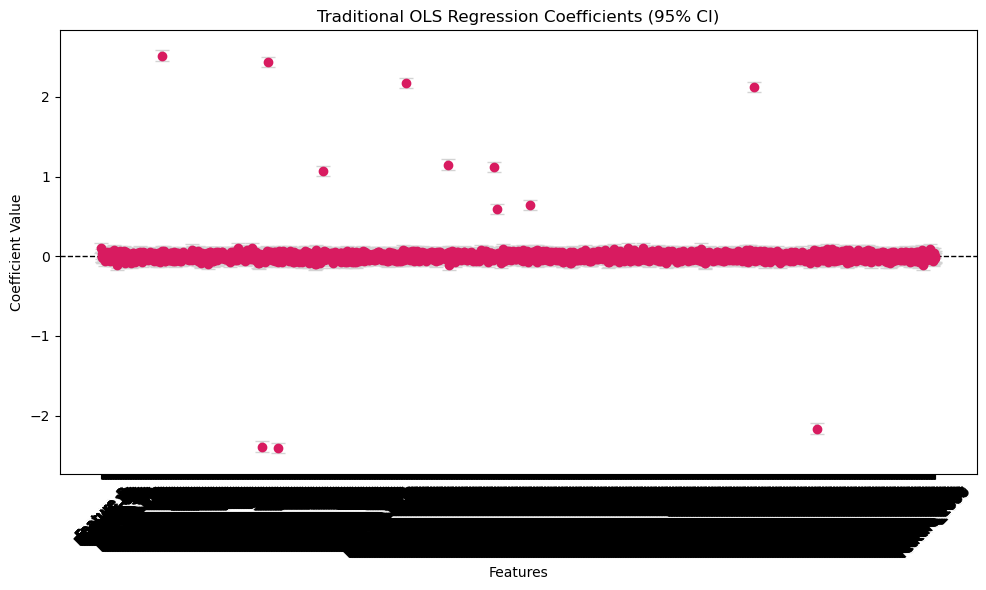

OLS Significant Features: {'Feature_218': {'pvalue': 0.0, 'coefficient': 2.5184369884289572}, 'Feature_578': {'pvalue': 0.0, 'coefficient': -2.389202565904135}, 'Feature_600': {'pvalue': 0.0, 'coefficient': 2.437147089199178}, 'Feature_635': {'pvalue': 0.0, 'coefficient': -2.410169576819535}, 'Feature_1097': {'pvalue': 0.0, 'coefficient': 2.1754307132687263}, 'Feature_2347': {'pvalue': 0.0, 'coefficient': 2.126088355187772}, 'Feature_2575': {'pvalue': 0.0, 'coefficient': -2.1636785414997637}, 'Feature_1248': {'pvalue': 4.1907057674521593e-259, 'coefficient': 1.1505519870254317}, 'Feature_1413': {'pvalue': 4.517237466090701e-246, 'coefficient': 1.122937931321614}, 'Feature_797': {'pvalue': 1.0882441576178257e-222, 'coefficient': 1.0704952401928693}, 'Feature_1542': {'pvalue': 1.464783240344437e-82, 'coefficient': 0.6425883777729339}, 'Feature_1423': {'pvalue': 2.5394594869173778e-70, 'coefficient': 0.590143076053982}}
Execution time: 71.77505683898926 seconds


In [33]:

# 2. Traditional Baseline (OLS)
start_time = time.time()
ols_model, significant_features = perform_traditional_regression(X_train, y_train)
end_time = time.time()

print("OLS Significant Features:", significant_features)
print(f"Execution time: {end_time - start_time} seconds")


#### test Traditional Baseline (OLS) results

In [34]:

print("Testing Traditional Baseline (OLS):")
# metrics = evaluate_feature_discovery(significant_features, true_linear_weights, true_interaction_weights)
metrics = evaluate_feature_discovery(
    detected_features=significant_features,
    ground_truth=ground_truth,
    evaluated_features=None,
)

# print("Testing String Input:")
# # metrics2 = evaluate_feature_discovery(list(significant_features.keys()), true_linear_weights, true_interaction_weights)
# metrics2 = evaluate_feature_discovery(
#     detected_features=list(significant_features.keys()),
#     ground_truth=ground_truth,
#     evaluated_features=None,
# )

# metrics

Testing Traditional Baseline (OLS):
        FEATURE DISCOVERY EVALUATION             
Overall Precision : 1.0000 (12/12)
Overall Recall    : 0.3000 (12/40)
Overall F1-Score  : 0.4615
False Positives   : []

---------------- Category Breakdown --------------

[LINEAR]
  True Features     : ['Feature_1097', 'Feature_1248', 'Feature_1413', 'Feature_1423', 'Feature_1542', 'Feature_218', 'Feature_2347', 'Feature_2575', 'Feature_2597', 'Feature_578', 'Feature_600', 'Feature_635', 'Feature_797']
  Detected          : ['Feature_1097', 'Feature_1248', 'Feature_1413', 'Feature_1423', 'Feature_1542', 'Feature_218', 'Feature_2347', 'Feature_2575', 'Feature_578', 'Feature_600', 'Feature_635', 'Feature_797']
  Missed            : ['Feature_2597']
  Recall            : 0.9231 (12/13)

[POLY]
  True Features     : ['Feature_2675', 'Feature_2761', 'Feature_768']
  Detected          : []
  Missed            : ['Feature_2675', 'Feature_2761', 'Feature_768']
  Recall            : 0.0000 (0/3)

[V_SHAPED]


In [35]:
significant_features
ols_model.summary()


coefs = ols_model.params.drop('const')
pvalues = ols_model.pvalues.drop('const')
conf_int = ols_model.conf_int().drop('const')

ols_results_df = pd.DataFrame({
    'feature': coefs.index,
    'coefficient': coefs,
    'p_value': pvalues,
    'ci_lower': conf_int[0],
    'ci_upper': conf_int[1]
})
ols_results_df.sort_values(by='p_value', inplace=True)
ols_results_df.set_index('feature', inplace=True)
ols_results_df


# get a list of the union of the keys of true_linear_weights and true_interaction_weights
# all_keys = set(true_linear_weights.keys()) | set(true_interaction_weights.keys())
all_keys = (
    set(ground_truth["linear"].keys())
    | set(ground_truth["poly"].keys())
    | set(ground_truth["v_shaped"].keys())
    | {f for item in ground_truth["interactions"] for f in item["features"]}
)
all_visible_keys = {f for f in all_keys if not f.startswith("Hidden_")}
all_keys = all_visible_keys
all_keys

print("Mean OLS coefficient for true contributing features:", ols_results_df[ols_results_df.index.isin(all_keys)]['coefficient'].mean())
print("Mean OLS coefficient for non-contributing features:", ols_results_df[~ols_results_df.index.isin(all_keys)]['coefficient'].mean())

print("Mean OLS p-value for true contributing features:", ols_results_df[ols_results_df.index.isin(all_keys)]['p_value'].mean())
print("Mean OLS p-value for non-contributing features:", ols_results_df[~ols_results_df.index.isin(all_keys)]['p_value'].mean())

ols_results_df[ols_results_df.index.isin(all_keys)].sort_values(by='p_value', ascending=True)


Mean OLS coefficient for true contributing features: 0.1685894856838291
Mean OLS coefficient for non-contributing features: -0.0008042483397670858
Mean OLS p-value for true contributing features: 0.36920129605929164
Mean OLS p-value for non-contributing features: 0.5028325970702939


,coefficient,p_value,ci_lower,ci_upper
feature,,,,
Feature_2347,2.126088,0.000000e+00,2.061087,2.191090
Feature_2575,-2.163679,0.000000e+00,-2.229165,-2.098192
Feature_1097,2.175431,0.000000e+00,2.110020,2.240842
Feature_218,2.518437,0.000000e+00,2.453196,2.583678
Feature_635,-2.410170,0.000000e+00,-2.475329,-2.345010
Feature_600,2.437147,0.000000e+00,2.371811,2.502483
Feature_578,-2.389203,0.000000e+00,-2.454431,-2.323974
Feature_1248,1.150552,4.190706e-259,1.085492,1.215612
Feature_1413,1.122938,4.517237e-246,1.057739,1.188137


## make a simple xgboost model for test 4

In [36]:

# 3. Machine Learning Modeling (XGBoost)
# We pass the pre-split data directly to ensure apples-to-apples comparison
start_time = time.time()
small_xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, base_score=np.mean(y_train), missing=np.nan, n_jobs=-1)
small_xgb_model.fit(X_train, y_train)

# Evaluate the XGBoost Model on the test set
evaluate_xgb_model(small_xgb_model, X_test, y_test)
end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")



--- XGBoost Performance (Testing) ---
R-squared Score:                0.4815
Mean Squared Error (MSE):       12.9256
Root Mean Squared Error (RMSE): 3.5952
Mean Absolute Error (MAE):      2.8481
-------------------------------------

Execution time: 168.59344482421875 seconds


In [37]:

# 3. Machine Learning Modeling (XGBoost)
# We pass the pre-split data directly to ensure apples-to-apples comparison
start_time = time.time()
big_xgb_model = xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, base_score=np.mean(y_train), missing=np.nan, n_jobs=-1)
big_xgb_model.fit(X_train, y_train)

# Evaluate the XGBoost Model on the test set
evaluate_xgb_model(big_xgb_model, X_test, y_test)
end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")




--- XGBoost Performance (Testing) ---
R-squared Score:                0.4965
Mean Squared Error (MSE):       12.5526
Root Mean Squared Error (RMSE): 3.5430
Mean Absolute Error (MAE):      2.7949
-------------------------------------

Execution time: 442.3463213443756 seconds


In [38]:

# 3. Machine Learning Modeling (XGBoost)
# We pass the pre-split data directly to ensure apples-to-apples comparison
start_time = time.time()
big_xgb_model_2_W = xgb.XGBRegressor(n_estimators=400, max_depth=5, learning_rate=0.1, base_score=np.mean(y_train), missing=np.nan, n_jobs=-1)
big_xgb_model_2_W.fit(X_train, y_train)

# Evaluate the XGBoost Model on the test set
evaluate_xgb_model(big_xgb_model_2_W, X_test, y_test)
end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")




--- XGBoost Performance (Testing) ---
R-squared Score:                0.4945
Mean Squared Error (MSE):       12.6007
Root Mean Squared Error (RMSE): 3.5498
Mean Absolute Error (MAE):      2.7997
-------------------------------------

Execution time: 824.602144241333 seconds


In [39]:

# 3. Machine Learning Modeling (XGBoost)
# We pass the pre-split data directly to ensure apples-to-apples comparison
start_time = time.time()
big_xgb_model_2_D = xgb.XGBRegressor(n_estimators=200, max_depth=7, learning_rate=0.1, base_score=np.mean(y_train), missing=np.nan, n_jobs=-1)
big_xgb_model_2_D.fit(X_train, y_train)

# Evaluate the XGBoost Model on the test set
evaluate_xgb_model(big_xgb_model_2_D, X_test, y_test)
end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")




--- XGBoost Performance (Testing) ---
R-squared Score:                0.4829
Mean Squared Error (MSE):       12.8906
Root Mean Squared Error (RMSE): 3.5903
Mean Absolute Error (MAE):      2.8391
-------------------------------------

Execution time: 741.7482807636261 seconds


In [40]:


model = big_xgb_model


### look at XGBoost Native Importances

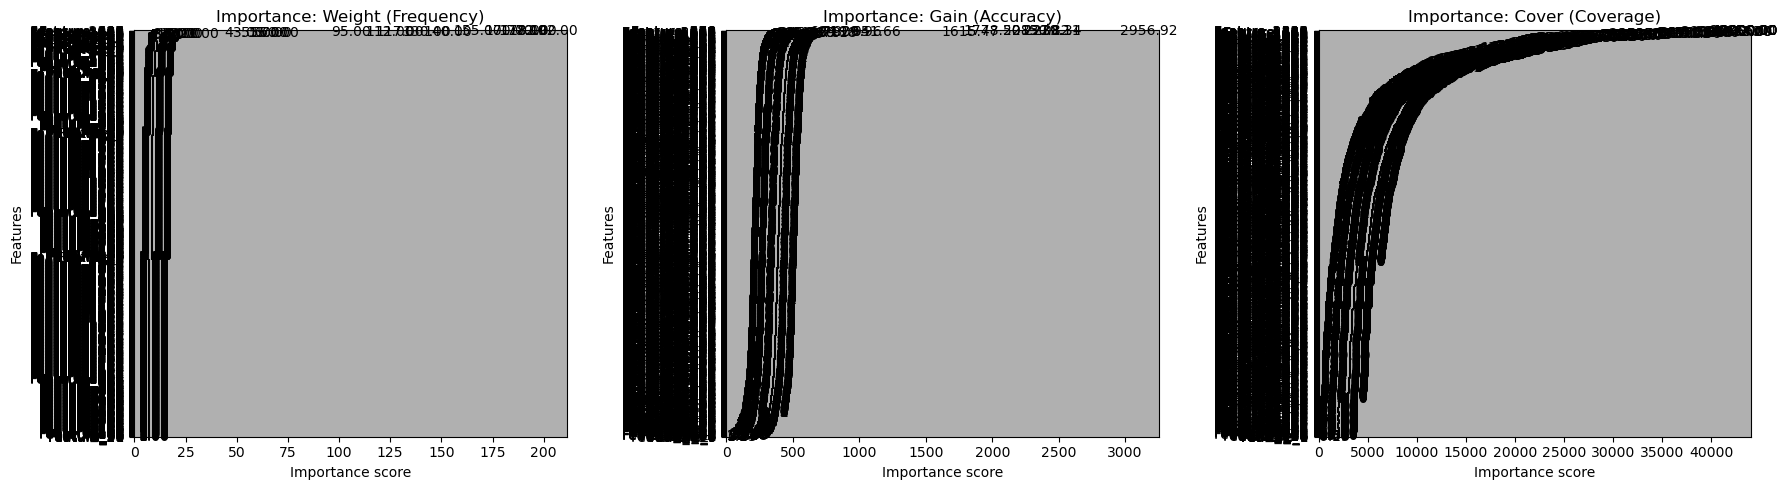

XGBoost Weight Importance: {'Feature_0': 21.0, 'Feature_1': 8.0, 'Feature_2': 10.0, 'Feature_3': 11.0, 'Feature_4': 6.0, 'Feature_5': 5.0, 'Feature_6': 3.0, 'Feature_7': 3.0, 'Feature_8': 5.0, 'Feature_9': 2.0, 'Feature_10': 5.0, 'Feature_11': 4.0, 'Feature_12': 4.0, 'Feature_13': 2.0, 'Feature_14': 5.0, 'Feature_15': 2.0, 'Feature_16': 2.0, 'Feature_17': 7.0, 'Feature_18': 4.0, 'Feature_19': 3.0, 'Feature_20': 1.0, 'Feature_21': 1.0, 'Feature_22': 2.0, 'Feature_24': 1.0, 'Feature_25': 4.0, 'Feature_26': 4.0, 'Feature_27': 5.0, 'Feature_28': 3.0, 'Feature_30': 3.0, 'Feature_32': 3.0, 'Feature_33': 2.0, 'Feature_34': 2.0, 'Feature_35': 3.0, 'Feature_36': 1.0, 'Feature_37': 1.0, 'Feature_38': 4.0, 'Feature_40': 4.0, 'Feature_41': 3.0, 'Feature_42': 2.0, 'Feature_43': 3.0, 'Feature_44': 4.0, 'Feature_45': 2.0, 'Feature_46': 2.0, 'Feature_47': 2.0, 'Feature_49': 2.0, 'Feature_51': 4.0, 'Feature_52': 1.0, 'Feature_53': 2.0, 'Feature_55': 2.0, 'Feature_56': 3.0, 'Feature_57': 1.0, 'Feature_5

In [41]:

# 4. XGBoost Native Importances
weight_importance, gain_importance, cover_importance = plot_all_xgb_importances(model)

print("XGBoost Weight Importance:", weight_importance)
print("XGBoost Gain Importance:", gain_importance)
print("XGBoost Cover Importance:", cover_importance)


#### test XGBoost Native Importances results

In [42]:

C = 1.0 # Adjust this constant to be more or less strict in filtering features based on standard deviation

significant_features = weight_importance
# get only values above the mean
significant_features = {k: v for k, v in significant_features.items() if v > np.mean(list(significant_features.values())) +C*np.std(list(significant_features.values()))}
significant_features 

print("Testing weight_importance:")
# metrics = evaluate_feature_discovery(significant_features, true_linear_weights, true_interaction_weights)
metrics = evaluate_feature_discovery(
    detected_features=significant_features,
    ground_truth=ground_truth,
    evaluated_features=None,
)
significant_features = gain_importance
# get only values above the mean
significant_features = {k: v for k, v in significant_features.items() if v > np.mean(list(significant_features.values())) +C*np.std(list(significant_features.values()))}
significant_features 

print("Testing gain_importance:")
# metrics = evaluate_feature_discovery(significant_features, true_linear_weights, true_interaction_weights)
metrics = evaluate_feature_discovery(
    detected_features=significant_features,
    ground_truth=ground_truth,
    evaluated_features=None,
)

significant_features = cover_importance
# get only values above the mean
significant_features = {k: v for k, v in significant_features.items() if v > np.mean(list(significant_features.values())) +C*np.std(list(significant_features.values()))}
significant_features 

print("Testing cover_importance:")
# metrics = evaluate_feature_discovery(significant_features, true_linear_weights, true_interaction_weights)
metrics = evaluate_feature_discovery(
    detected_features=significant_features,
    ground_truth=ground_truth,
    evaluated_features=None,
)


Testing weight_importance:
        FEATURE DISCOVERY EVALUATION             
Overall Precision : 0.9412 (16/17)
Overall Recall    : 0.4000 (16/40)
Overall F1-Score  : 0.5614
False Positives   : ['Feature_0']

---------------- Category Breakdown --------------

[LINEAR]
  True Features     : ['Feature_1097', 'Feature_1248', 'Feature_1413', 'Feature_1423', 'Feature_1542', 'Feature_218', 'Feature_2347', 'Feature_2575', 'Feature_2597', 'Feature_578', 'Feature_600', 'Feature_635', 'Feature_797']
  Detected          : ['Feature_1097', 'Feature_1248', 'Feature_1413', 'Feature_1423', 'Feature_1542', 'Feature_218', 'Feature_2347', 'Feature_2575', 'Feature_578', 'Feature_600', 'Feature_635', 'Feature_797']
  Missed            : ['Feature_2597']
  Recall            : 0.9231 (12/13)

[POLY]
  True Features     : ['Feature_2675', 'Feature_2761', 'Feature_768']
  Detected          : ['Feature_2675', 'Feature_2761', 'Feature_768']
  Missed            : []
  Recall            : 1.0000 (3/3)

[V_SHAPED

In [43]:


# get a list of the union of the keys of true_linear_weights and true_interaction_weights
# all_keys = set(true_linear_weights.keys()) | set(true_interaction_weights.keys())
all_keys = (
    set(ground_truth["linear"].keys())
    | set(ground_truth["poly"].keys())
    | set(ground_truth["v_shaped"].keys())
    | {f for item in ground_truth["interactions"] for f in item["features"]}
)
all_visible_keys = {f for f in all_keys if not f.startswith("Hidden_")}
all_keys = all_visible_keys
all_keys

print("Mean XGBoost weight importance for true contributing features:", np.mean([weight_importance.get(k, 0) for k in all_keys]))
print("Mean XGBoost weight importance for non-contributing features:", np.mean([weight_importance.get(k, 0) for k in weight_importance if k not in all_keys]))

print("STD XGBoost weight importance for all features:", np.std([weight_importance.get(k, 0) for k in weight_importance]))

# Get the weight importances for all keys
weight_importances_for_all_keys = {k: weight_importance.get(k, 0) for k in all_keys}
# Sort by importance
sorted_weight_importances = dict(sorted(weight_importances_for_all_keys.items(), key=lambda item: item[1], reverse=True))
print("XGBoost weight importance for all contributing features (sorted):")
sorted_weight_importances



Mean XGBoost weight importance for true contributing features: 49.5
Mean XGBoost weight importance for non-contributing features: 1.9534774436090225
STD XGBoost weight importance for all features: 11.096365117245329
XGBoost weight importance for all contributing features (sorted):


{'Feature_2347': 192.0,
 'Feature_635': 182.0,
 'Feature_600': 178.0,
 'Feature_2575': 177.0,
 'Feature_578': 170.0,
 'Feature_1097': 155.0,
 'Feature_218': 140.0,
 'Feature_311': 130.0,
 'Feature_1248': 117.0,
 'Feature_797': 112.0,
 'Feature_1413': 95.0,
 'Feature_1542': 60.0,
 'Feature_1423': 57.0,
 'Feature_768': 55.0,
 'Feature_2675': 51.0,
 'Feature_2761': 43.0,
 'Feature_959': 13.0,
 'Feature_1250': 12.0,
 'Feature_1856': 4.0,
 'Feature_173': 4.0,
 'Feature_1515': 4.0,
 'Feature_1998': 3.0,
 'Feature_2881': 3.0,
 'Feature_680': 3.0,
 'Feature_2412': 3.0,
 'Feature_1140': 3.0,
 'Feature_2904': 2.0,
 'Feature_458': 2.0,
 'Feature_577': 2.0,
 'Feature_2367': 2.0,
 'Feature_2597': 2.0,
 'Feature_2295': 1.0,
 'Feature_2382': 1.0,
 'Feature_1260': 1.0,
 'Feature_362': 1.0,
 'Feature_1384': 0,
 'Feature_1689': 0,
 'Feature_1101': 0,
 'Feature_2496': 0,
 'Feature_832': 0}

In [44]:


# get a list of the union of the keys of true_linear_weights and true_interaction_weights
# all_keys = set(true_linear_weights.keys()) | set(true_interaction_weights.keys())
all_keys = (
    set(ground_truth["linear"].keys())
    | set(ground_truth["poly"].keys())
    | set(ground_truth["v_shaped"].keys())
    | {f for item in ground_truth["interactions"] for f in item["features"]}
)
all_visible_keys = {f for f in all_keys if not f.startswith("Hidden_")}
all_keys = all_visible_keys
all_keys

print("Mean XGBoost gain importance for true contributing features:", np.mean([gain_importance.get(k, 0) for k in all_keys]))
print("Mean XGBoost gain importance for non-contributing features:", np.mean([gain_importance.get(k, 0) for k in gain_importance if k not in all_keys]))

print("STD of XGBoost gain importance for all features:", np.std(list(gain_importance.values())))

# Get the gain importances for all keys
gain_importances_for_all_keys = {k: gain_importance.get(k, 0) for k in all_keys}
# Sort by importance
sorted_gain_importances = dict(sorted(gain_importances_for_all_keys.items(), key=lambda item: item[1], reverse=True))
print("XGBoost gain importance for all contributing features (sorted):")
sorted_gain_importances



Mean XGBoost gain importance for true contributing features: 606.9361396789551
Mean XGBoost gain importance for non-contributing features: 174.57710075490456
STD of XGBoost gain importance for all features: 126.80628491679275
XGBoost gain importance for all contributing features (sorted):


{'Feature_218': 2956.91943359375,
 'Feature_600': 2238.33837890625,
 'Feature_578': 2229.11083984375,
 'Feature_635': 2150.123779296875,
 'Feature_1097': 2083.084228515625,
 'Feature_2575': 1778.4991455078125,
 'Feature_2347': 1615.4681396484375,
 'Feature_1413': 941.6641235351562,
 'Feature_1248': 800.9615478515625,
 'Feature_797': 719.6471557617188,
 'Feature_959': 624.2871704101562,
 'Feature_311': 610.1761474609375,
 'Feature_1542': 500.7894592285156,
 'Feature_1423': 459.6453552246094,
 'Feature_768': 396.0865173339844,
 'Feature_1250': 354.8833312988281,
 'Feature_2675': 323.2296142578125,
 'Feature_680': 274.84332275390625,
 'Feature_2761': 273.3767395019531,
 'Feature_2412': 240.52256774902344,
 'Feature_1140': 234.48728942871094,
 'Feature_1998': 231.61375427246094,
 'Feature_1515': 201.52154541015625,
 'Feature_2382': 197.53793334960938,
 'Feature_2597': 195.44931030273438,
 'Feature_173': 190.8295135498047,
 'Feature_1856': 182.99359130859375,
 'Feature_2367': 175.4190979003

In [45]:


# get a list of the union of the keys of true_linear_weights and true_interaction_weights
# all_keys = set(true_linear_weights.keys()) | set(true_interaction_weights.keys())
all_keys = (
    set(ground_truth["linear"].keys())
    | set(ground_truth["poly"].keys())
    | set(ground_truth["v_shaped"].keys())
    | {f for item in ground_truth["interactions"] for f in item["features"]}
)
all_visible_keys = {f for f in all_keys if not f.startswith("Hidden_")}
all_keys = all_visible_keys
all_keys

print("Mean XGBoost cover importance for true contributing features:", np.mean([cover_importance.get(k, 0) for k in all_keys]))
print("Mean XGBoost cover importance for non-contributing features:", np.mean([cover_importance.get(k, 0) for k in cover_importance if k not in all_keys]))

print("STD XGBoost cover importance for all features:", np.std([cover_importance.get(k, 0) for k in cover_importance]))

# Get the cover importances for all keys
cover_importances_for_all_keys = {k: cover_importance.get(k, 0) for k in all_keys}
# Sort by importance
sorted_cover_importances = dict(sorted(cover_importances_for_all_keys.items(), key=lambda item: item[1], reverse=True))
print("XGBoost cover importance for all contributing features (sorted):")
sorted_cover_importances



Mean XGBoost cover importance for true contributing features: 6930.4250587463375
Mean XGBoost cover importance for non-contributing features: 3384.3760203882716
STD XGBoost cover importance for all features: 5787.509654004571
XGBoost cover importance for all contributing features (sorted):


{'Feature_768': 22207.21875,
 'Feature_2675': 19133.234375,
 'Feature_2761': 18736.326171875,
 'Feature_1542': 15928.7001953125,
 'Feature_1423': 14692.89453125,
 'Feature_218': 14319.12109375,
 'Feature_311': 14004.6767578125,
 'Feature_1413': 13730.642578125,
 'Feature_1250': 12891.9169921875,
 'Feature_797': 12010.6962890625,
 'Feature_1248': 11821.931640625,
 'Feature_1097': 11568.361328125,
 'Feature_578': 11446.4765625,
 'Feature_600': 11098.2470703125,
 'Feature_635': 10766.1865234375,
 'Feature_2575': 10507.74609375,
 'Feature_2347': 9644.734375,
 'Feature_959': 9184.3076171875,
 'Feature_2412': 5570.33349609375,
 'Feature_1515': 5250.5,
 'Feature_2382': 3546.0,
 'Feature_577': 3456.0,
 'Feature_1998': 2957.0,
 'Feature_173': 2013.5,
 'Feature_2367': 1867.5,
 'Feature_680': 1813.6666259765625,
 'Feature_1260': 1634.0,
 'Feature_1856': 1491.75,
 'Feature_2881': 1471.6666259765625,
 'Feature_2597': 1139.5,
 'Feature_1140': 471.6666564941406,
 'Feature_362': 303.0,
 'Feature_2295'

### try to use SHAP to find the influencing inputs

In [46]:

# 5. Explainability (SHAP)
start_time = time.time()
shap_values = compute_shap_values(model, X_train, X_test)
end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")


Execution time: 5.677367448806763 seconds


#### individual SHAP features ranking

Plotting SHAP analysis for top 5 features: ['Feature_218', 'Feature_635', 'Feature_600', 'Feature_578', 'Feature_1097']


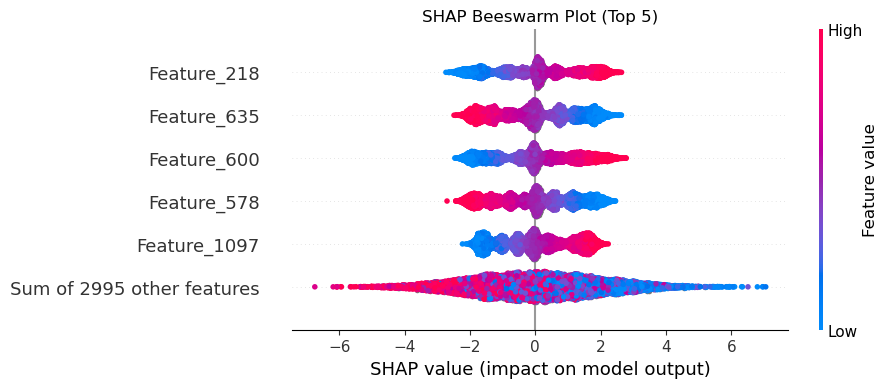

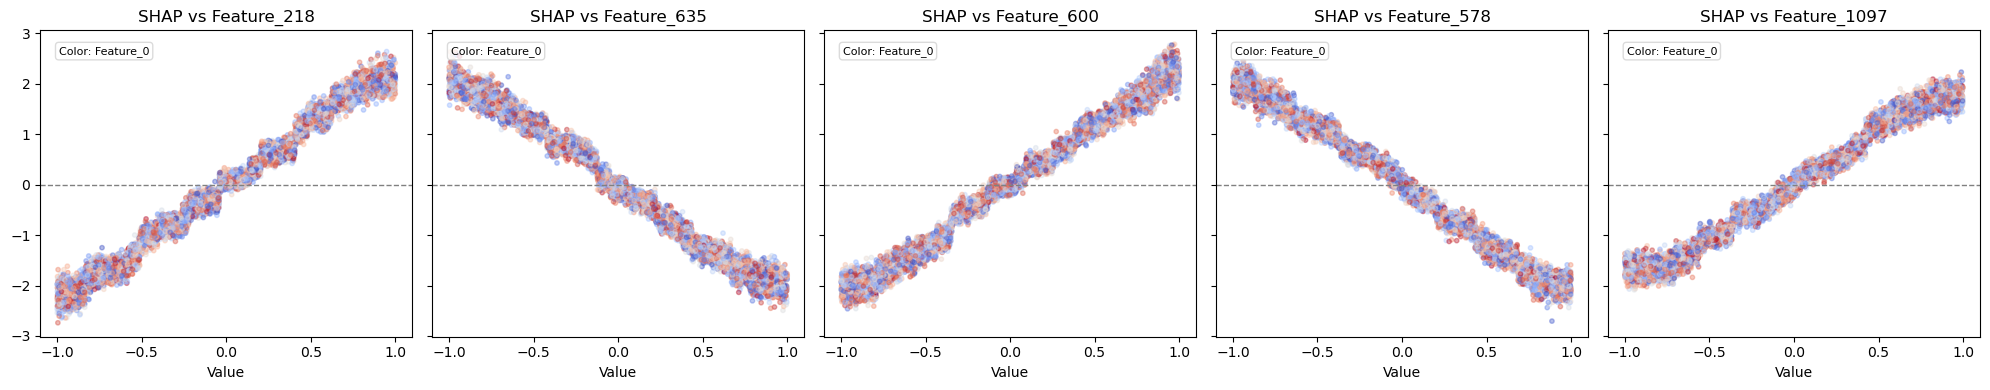

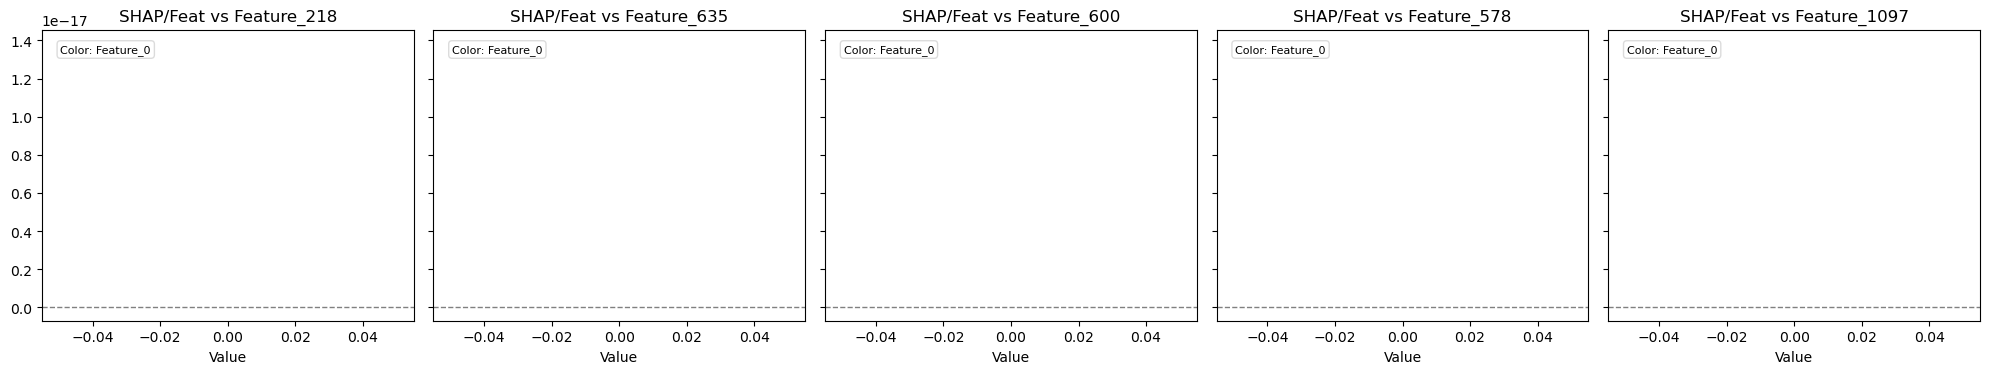

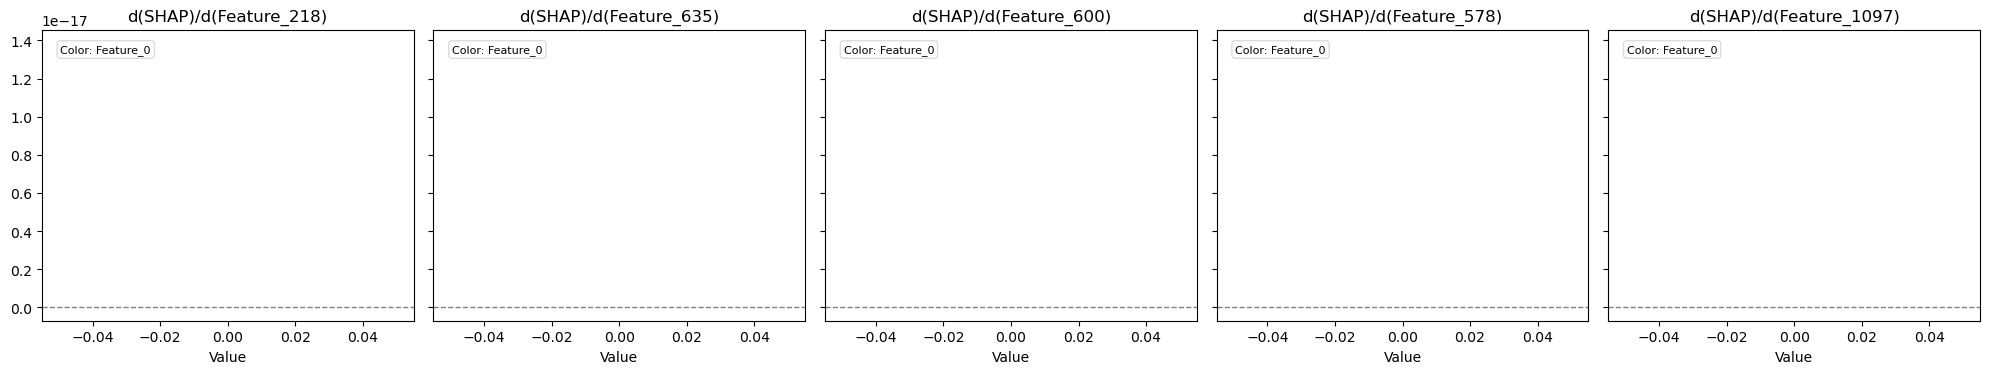

In [ ]:

# 6. Visualization (SHAP)
plot_shap_analysis(shap_values, feature_names=X_train.columns)


#### SHAP summry

In [53]:

# 8. Summary (SHAP)
ranked_features = print_feature_importance(shap_values)

print("Ranked Features by SHAP Importance:", ranked_features)



--- SHAP Feature Importance Ranking ---
SHAP Global Importance Dictionary:
  Feature_218: 1.0732
  Feature_635: 1.0491
  Feature_600: 1.0474
  Feature_578: 1.0266
  Feature_1097: 0.9445
  Feature_2575: 0.9377
  Feature_2347: 0.9088
  Feature_1248: 0.4659
  Feature_1413: 0.4537
  Feature_797: 0.4234
  Feature_311: 0.3998
  Feature_1542: 0.2285
  Feature_1423: 0.2151
  Feature_768: 0.1944
  Feature_2675: 0.1498
  Feature_2761: 0.1150
  Feature_1250: 0.0301
  Feature_959: 0.0257
  Feature_793: 0.0195
  Feature_2012: 0.0169
  Feature_1249: 0.0157
  Feature_2956: 0.0157
  Feature_772: 0.0152
  Feature_1845: 0.0152
  Feature_1905: 0.0147
  Feature_1329: 0.0139
  Feature_2122: 0.0133
  Feature_2325: 0.0128
  Feature_2279: 0.0126
  Feature_287: 0.0125
  Feature_1661: 0.0124
  Feature_644: 0.0122
  Feature_1369: 0.0122
  Feature_0: 0.0121
  Feature_1443: 0.0120
  Feature_2494: 0.0119
  Feature_624: 0.0113
  Feature_356: 0.0111
  Feature_649: 0.0110
  Feature_262: 0.0109
  Feature_1401: 0.0108


#### test SHAP Importances results

In [54]:
C = 1.0 # Adjust this constant to be more or less strict in filtering features based on standard deviation

significant_features = ranked_features
# get only values above the mean
significant_features = {k: v for k, v in significant_features.items() if v > np.mean(list(significant_features.values())) +C*np.std(list(significant_features.values()))}
significant_features 

print("Testing SHAP importance:")
# metrics = evaluate_feature_discovery(significant_features, true_linear_weights, true_interaction_weights)
metrics = evaluate_feature_discovery(
    detected_features=significant_features,
    ground_truth=ground_truth,
    evaluated_features=None,
)



Testing SHAP importance:
        FEATURE DISCOVERY EVALUATION             
Overall Precision : 1.0000 (16/16)
Overall Recall    : 0.4000 (16/40)
Overall F1-Score  : 0.5714
False Positives   : []

---------------- Category Breakdown --------------

[LINEAR]
  True Features     : ['Feature_1097', 'Feature_1248', 'Feature_1413', 'Feature_1423', 'Feature_1542', 'Feature_218', 'Feature_2347', 'Feature_2575', 'Feature_2597', 'Feature_578', 'Feature_600', 'Feature_635', 'Feature_797']
  Detected          : ['Feature_1097', 'Feature_1248', 'Feature_1413', 'Feature_1423', 'Feature_1542', 'Feature_218', 'Feature_2347', 'Feature_2575', 'Feature_578', 'Feature_600', 'Feature_635', 'Feature_797']
  Missed            : ['Feature_2597']
  Recall            : 0.9231 (12/13)

[POLY]
  True Features     : ['Feature_2675', 'Feature_2761', 'Feature_768']
  Detected          : ['Feature_2675', 'Feature_2761', 'Feature_768']
  Missed            : []
  Recall            : 1.0000 (3/3)

[V_SHAPED]
  True Feat

In [55]:


# get a list of the union of the keys of true_linear_weights and true_interaction_weights
# all_keys = set(true_linear_weights.keys()) | set(true_interaction_weights.keys())
all_keys = (
    set(ground_truth["linear"].keys())
    | set(ground_truth["poly"].keys())
    | set(ground_truth["v_shaped"].keys())
    | {f for item in ground_truth["interactions"] for f in item["features"]}
)
all_visible_keys = {f for f in all_keys if not f.startswith("Hidden_")}
all_keys = all_visible_keys
all_keys

print("Mean XGBoost SHAP importance for true contributing features:", np.mean([ranked_features.get(k, 0) for k in all_keys]))
print("Mean XGBoost SHAP importance for non-contributing features:", np.mean([ranked_features.get(k, 0) for k in ranked_features if k not in all_keys]))

print("STD XGBoost SHAP importance for all features:", np.std([ranked_features.get(k, 0) for k in ranked_features]))

# Get the SHAP importances for all keys
shap_importances_for_all_keys = {k: ranked_features.get(k, 0) for k in all_keys}
# Sort by importance
sorted_shap_importances = dict(sorted(shap_importances_for_all_keys.items(), key=lambda item: item[1], reverse=True))
print("XGBoost SHAP importance for all contributing features (sorted):")
sorted_shap_importances



Mean XGBoost SHAP importance for true contributing features: 0.24303588
Mean XGBoost SHAP importance for non-contributing features: 0.00135054
STD XGBoost SHAP importance for all features: 0.051283706
XGBoost SHAP importance for all contributing features (sorted):


{'Feature_218': 1.073196,
 'Feature_635': 1.0490637,
 'Feature_600': 1.0474046,
 'Feature_578': 1.0266207,
 'Feature_1097': 0.9445146,
 'Feature_2575': 0.937724,
 'Feature_2347': 0.9087917,
 'Feature_1248': 0.4659462,
 'Feature_1413': 0.4536832,
 'Feature_797': 0.42340285,
 'Feature_311': 0.39983103,
 'Feature_1542': 0.22846948,
 'Feature_1423': 0.21509111,
 'Feature_768': 0.19435869,
 'Feature_2675': 0.1498228,
 'Feature_2761': 0.114967,
 'Feature_1250': 0.030069858,
 'Feature_959': 0.025694791,
 'Feature_1515': 0.0066517326,
 'Feature_2412': 0.004106037,
 'Feature_1998': 0.003324421,
 'Feature_173': 0.0027987792,
 'Feature_680': 0.002151793,
 'Feature_1140': 0.001958754,
 'Feature_1856': 0.001841341,
 'Feature_577': 0.0017732912,
 'Feature_2382': 0.0016338126,
 'Feature_2881': 0.001509179,
 'Feature_1260': 0.0013503872,
 'Feature_2367': 0.00095967494,
 'Feature_2597': 0.00093948527,
 'Feature_2904': 0.00061058823,
 'Feature_2295': 0.0005390531,
 'Feature_458': 0.0004978827,
 'Feature

## try SAGE (Shapley Additive Global importancE) importance

In [56]:

import sage
import pandas as pd
import numpy as np

def compute_sage_importance(model, X_train, X_test, y_test, feature_names):
    """
    Computes global feature importance using SAGE.
    Measures the exact reduction in Mean Squared Error (MSE) each feature contributes.
    """
    print("\n[SAGE] Computing global loss-reduction values...")
    
    # 1. Set up a marginal imputer using a background sample from X_train.
    bg_sample = X_train.head(512).values if isinstance(X_train, pd.DataFrame) else X_train[:512]
    imputer = sage.MarginalImputer(model, bg_sample)
    
    # 2. Set up the estimator using 'mse' to match continuous regression targets
    estimator = sage.PermutationEstimator(imputer, 'mse')
    
    # 3. FIX: Convert BOTH X and y to numpy arrays to prevent pandas indexing mismatches
    X_test_arr = X_test.values if isinstance(X_test, pd.DataFrame) else X_test
    y_test_arr = y_test.values if isinstance(y_test, pd.Series) else y_test
    
    # Calculate SAGE values
    sage_values = estimator(X_test_arr, y_test_arr,
                            n_permutations=10,         # Hard-cap the number of permutations
                            detect_convergence=False,  # Prevent it from looping until convergence
                            verbose=True)
    
    # 4. Map values to feature names and sort
    sage_ranked = dict(zip(feature_names, sage_values.values))
    sage_ranked = {k: v for k, v in sorted(sage_ranked.items(), key=lambda item: item[1], reverse=True)}
    
    return sage_ranked, sage_values


In [57]:
# ## to slow to be affective/work

# # sage_ranked, sage_values = compute_sage_importance(model, X_train, X_test, y_test, feature_names)

# # sage_ranked, sage_values

# # ==========================================
# # 11. SAGE GLOBAL IMPORTANCE ANALYSIS
# # ==========================================

# N = 100  # Number of samples to use for SAGE calculation (adjust as needed)

# sage_ranked, sage_values_obj = compute_sage_importance(
#     model=model,
#     X_train=X_train.iloc[:N, :],
#     X_test=X_test.iloc[:N, :],
#     y_test=y_test.iloc[:N],
#     feature_names=feature_names
# )

# # In SAGE, any feature with an importance > 0 actively reduces the model's error.
# # Features <= 0 are redundant or pure noise.
# significant_features_sage = {k: v for k, v in sage_ranked.items() if v > 0}

# print("\nTesting SAGE importance discovery:")
# metrics_sage = evaluate_feature_discovery(
#     significant_features_sage, 
#     true_linear_weights, 
#     true_interaction_weights
# )

# # Optional: You can also use the built-in plotting tool
# sage_values_obj.plot(feature_names)



## make simple CatBoost model

In [58]:
# Ensure catboost is installed: !pip install catboost
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def evaluate_catboost_model(model, X_test, y_test):
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    
    print("\n--- CatBoost Performance (Testing) ---")
    print(f"R-squared Score: {r2:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print("-------------------------------------")

In [59]:
# 3b. Machine Learning Modeling (CatBoost)
start_time = time.time()

# CatBoost parameters mapping:
# n_estimators -> iterations
# max_depth -> depth
# n_jobs -> thread_count
big_cat_model = CatBoostRegressor(
    iterations=200, 
    depth=5, 
    learning_rate=0.1, 
    thread_count=-1, 
    verbose=50 # Prints training loss every 50 iterations (set to False to turn off)
)

big_cat_model.fit(X_train, y_train)

# Evaluate on the pre-split test set
evaluate_catboost_model(big_cat_model, X_test, y_test)

end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")

0:	learn: 4.8870918	total: 572ms	remaining: 1m 53s
50:	learn: 3.7161996	total: 16.7s	remaining: 48.7s
100:	learn: 3.5420143	total: 32.5s	remaining: 31.8s
150:	learn: 3.4423648	total: 46.9s	remaining: 15.2s
199:	learn: 3.3736889	total: 1m 2s	remaining: 0us

--- CatBoost Performance (Testing) ---
R-squared Score: 0.5088
Mean Squared Error (MSE): 12.2446
Root Mean Squared Error (RMSE): 3.4992
Mean Absolute Error (MAE): 2.7655
-------------------------------------
Execution time: 65.64283466339111 seconds


In [60]:

# Variant 1: More estimators / iterations (matching big_model_2_W)
start_time = time.time()
cat_model_2_W = CatBoostRegressor(iterations=400, depth=5, learning_rate=0.1, thread_count=-1, verbose=100)
cat_model_2_W.fit(X_train, y_train)
evaluate_catboost_model(cat_model_2_W, X_test, y_test)
print(f"Execution time: {time.time() - start_time} seconds")



0:	learn: 4.8870918	total: 355ms	remaining: 2m 21s
100:	learn: 3.5420143	total: 31.8s	remaining: 1m 34s
200:	learn: 3.3724903	total: 59.1s	remaining: 58.5s
300:	learn: 3.2561235	total: 1m 27s	remaining: 28.6s
399:	learn: 3.1544833	total: 1m 57s	remaining: 0us

--- CatBoost Performance (Testing) ---
R-squared Score: 0.5152
Mean Squared Error (MSE): 12.0859
Root Mean Squared Error (RMSE): 3.4765
Mean Absolute Error (MAE): 2.7461
-------------------------------------
Execution time: 120.81982684135437 seconds


In [61]:

# Variant 2: Deeper trees (matching big_model_2_D)
start_time = time.time()
cat_model_2_D = CatBoostRegressor(iterations=200, depth=7, learning_rate=0.1, thread_count=-1, verbose=50)
cat_model_2_D.fit(X_train, y_train)
evaluate_catboost_model(cat_model_2_D, X_test, y_test)
print(f"Execution time: {time.time() - start_time} seconds")


0:	learn: 4.8497697	total: 931ms	remaining: 3m 5s
50:	learn: 3.6215471	total: 41.8s	remaining: 2m 2s
100:	learn: 3.4552377	total: 1m 20s	remaining: 1m 18s
150:	learn: 3.3217945	total: 1m 57s	remaining: 38.2s
199:	learn: 3.1980384	total: 2m 35s	remaining: 0us

--- CatBoost Performance (Testing) ---
R-squared Score: 0.5116
Mean Squared Error (MSE): 12.1756
Root Mean Squared Error (RMSE): 3.4893
Mean Absolute Error (MAE): 2.7517
-------------------------------------
Execution time: 159.2931571006775 seconds


## make simple LightGBM model

In [62]:
# Ensure lightgbm is installed: !pip install lightgbm
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def evaluate_lgbm_model(model, X_test, y_test):
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    
    print("\n--- LightGBM Performance (Testing) ---")
    print(f"R-squared Score: {r2:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print("-------------------------------------")

In [63]:
# 3c. Machine Learning Modeling (LightGBM)
start_time = time.time()

big_lgbm_model = LGBMRegressor(
    n_estimators=200, 
    max_depth=5, 
    num_leaves=31, 
    learning_rate=0.1, 
    n_jobs=-1,
    random_state=42
)

big_lgbm_model.fit(X_train, y_train)

# Evaluate on the pre-split test set
evaluate_lgbm_model(big_lgbm_model, X_test, y_test)

end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.645789 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765000
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 3000
[LightGBM] [Info] Start training from score -1.746058
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

In [64]:


# Variant 1: More estimators (matching big_model_2_W)
start_time = time.time()
lgbm_model_2_W = LGBMRegressor(n_estimators=400, max_depth=5, num_leaves=31, learning_rate=0.1, n_jobs=-1, random_state=42)
lgbm_model_2_W.fit(X_train, y_train)
evaluate_lgbm_model(lgbm_model_2_W, X_test, y_test)
print(f"Execution time: {time.time() - start_time} seconds")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.573076 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765000
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 3000
[LightGBM] [Info] Start training from score -1.746058
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

In [65]:

# Variant 2: Deeper trees (matching big_model_2_D)
start_time = time.time()
# Adjusted num_leaves up to 63 to allow deeper trees (2^7 is max 128, 63 is standard for depth 7)
lgbm_model_2_D = LGBMRegressor(n_estimators=200, max_depth=7, num_leaves=63, learning_rate=0.1, n_jobs=-1, random_state=42)
lgbm_model_2_D.fit(X_train, y_train)
evaluate_lgbm_model(lgbm_model_2_D, X_test, y_test)
print(f"Execution time: {time.time() - start_time} seconds")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.586473 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765000
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 3000
[LightGBM] [Info] Start training from score -1.746058
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

## make simple Random Forest model

In [66]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import time

def evaluate_rf_model(model, X_test, y_test):
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    
    print("\n--- Random Forest Performance (Testing) ---")
    print(f"R-squared Score: {r2:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print("-----------------------------------------")

In [67]:

# 3d. Machine Learning Modeling (Random Forest)
start_time = time.time()

small_rf_model = RandomForestRegressor(
    n_estimators=100, 
    max_depth=3, 
    n_jobs=-1,
    random_state=42
)

small_rf_model.fit(X_train, y_train)

# Evaluate on the pre-split test set
evaluate_rf_model(small_rf_model, X_test, y_test)

end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")




--- Random Forest Performance (Testing) ---
R-squared Score: 0.2004
Mean Squared Error (MSE): 19.9326
Root Mean Squared Error (RMSE): 4.4646
Mean Absolute Error (MAE): 3.5600
-----------------------------------------
Execution time: 1244.2949826717377 seconds


In [68]:

# # take very long to run

# # 3d. Machine Learning Modeling (Random Forest)
# start_time = time.time()

# big_rf_model = RandomForestRegressor(
#     n_estimators=200, 
#     max_depth=5, 
#     n_jobs=-1,
#     random_state=42
# )

# big_rf_model.fit(X_train, y_train)

# # Evaluate on the pre-split test set
# evaluate_rf_model(big_rf_model, X_test, y_test)

# end_time = time.time()
# print(f"Execution time: {end_time - start_time} seconds")



In [69]:

# # take to long to run

# # Variant 1: More estimators (matching big_model_2_W)
# start_time = time.time()
# rf_model_2_W = RandomForestRegressor(n_estimators=400, max_depth=5, n_jobs=-1, random_state=42)
# rf_model_2_W.fit(X_train, y_train)
# evaluate_rf_model(rf_model_2_W, X_test, y_test)
# print(f"Execution time: {time.time() - start_time} seconds")


In [70]:


# # take to long to run

# # Variant 2: Deeper trees (matching big_model_2_D)
# start_time = time.time()
# rf_model_2_D = RandomForestRegressor(n_estimators=200, max_depth=7, n_jobs=-1, random_state=42)
# rf_model_2_D.fit(X_train, y_train)
# evaluate_rf_model(rf_model_2_D, X_test, y_test)
# print(f"Execution time: {time.time() - start_time} seconds")


## make simple Extremely Randomized Trees model

In [71]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import time

def evaluate_et_model(model, X_test, y_test):
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    
    print("\n--- Extra Trees Performance (Testing) ---")
    print(f"R-squared Score: {r2:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print("-----------------------------------------")

# Baseline Model (Matching big_model)
start_time = time.time()
big_et_model = ExtraTreesRegressor(n_estimators=200, max_depth=5, n_jobs=-1, random_state=42)
big_et_model.fit(X_train, y_train)
evaluate_et_model(big_et_model, X_test, y_test)
print(f"Execution time: {time.time() - start_time} seconds")



--- Extra Trees Performance (Testing) ---
R-squared Score: 0.3059
Mean Squared Error (MSE): 17.3037
Root Mean Squared Error (RMSE): 4.1598
Mean Absolute Error (MAE): 3.3122
-----------------------------------------
Execution time: 489.5433602333069 seconds


In [72]:

# Variant 1: More estimators (Matching big_model_2_W)
start_time = time.time()
et_model_2_W = ExtraTreesRegressor(n_estimators=400, max_depth=5, n_jobs=-1, random_state=42)
et_model_2_W.fit(X_train, y_train)
evaluate_et_model(et_model_2_W, X_test, y_test)
print(f"Execution time: {time.time() - start_time} seconds")



--- Extra Trees Performance (Testing) ---
R-squared Score: 0.3063
Mean Squared Error (MSE): 17.2929
Root Mean Squared Error (RMSE): 4.1585
Mean Absolute Error (MAE): 3.3120
-----------------------------------------
Execution time: 916.3003721237183 seconds


In [73]:

# Variant 2: Deeper trees (Matching big_model_2_D)
start_time = time.time()
et_model_2_D = ExtraTreesRegressor(n_estimators=200, max_depth=7, n_jobs=-1, random_state=42)
et_model_2_D.fit(X_train, y_train)
evaluate_et_model(et_model_2_D, X_test, y_test)
print(f"Execution time: {time.time() - start_time} seconds")


--- Extra Trees Performance (Testing) ---
R-squared Score: 0.3668
Mean Squared Error (MSE): 15.7844
Root Mean Squared Error (RMSE): 3.9730
Mean Absolute Error (MAE): 3.1626
-----------------------------------------
Execution time: 612.2126169204712 seconds


## make simple AdaBoost model

In [74]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import time

def evaluate_ada_model(model, X_test, y_test):
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    
    print("\n--- AdaBoost Performance (Testing) ---")
    print(f"R-squared Score: {r2:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print("--------------------------------------")


In [75]:

# # Baseline Model (Matching big_model)
# start_time = time.time()
# big_ada_model = AdaBoostRegressor(
#     estimator=DecisionTreeRegressor(max_depth=5),
#     n_estimators=200, 
#     learning_rate=0.1,
#     random_state=42
# )
# big_ada_model.fit(X_train, y_train)
# evaluate_ada_model(big_ada_model, X_test, y_test)
# print(f"Execution time: {time.time() - start_time} seconds")


In [76]:

# # Variant 1: More estimators (Matching big_model_2_W)
# start_time = time.time()
# ada_model_2_W = AdaBoostRegressor(
#     estimator=DecisionTreeRegressor(max_depth=5),
#     n_estimators=400, 
#     learning_rate=0.1,
#     random_state=42
# )
# ada_model_2_W.fit(X_train, y_train)
# evaluate_ada_model(ada_model_2_W, X_test, y_test)
# print(f"Execution time: {time.time() - start_time} seconds")


In [77]:

# # Variant 2: Deeper trees (Matching big_model_2_D)
# start_time = time.time()
# ada_model_2_D = AdaBoostRegressor(
#     estimator=DecisionTreeRegressor(max_depth=7),
#     n_estimators=200, 
#     learning_rate=0.1,
#     random_state=42
# )
# ada_model_2_D.fit(X_train, y_train)
# evaluate_ada_model(ada_model_2_D, X_test, y_test)
# print(f"Execution time: {time.time() - start_time} seconds")

## make simple HistGradientBoosting model 

In [78]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import time

def evaluate_hgb_model(model, X_test, y_test):
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    
    print("\n--- HistGradientBoosting Performance (Testing) ---")
    print(f"R-squared Score: {r2:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print("-------------------------------------------------")

In [79]:

# 3e. Machine Learning Modeling (HistGradientBoosting)
start_time = time.time()

# Note: max_iter is used instead of n_estimators
big_hgb_model = HistGradientBoostingRegressor(
    max_iter=200, 
    max_depth=5, 
    learning_rate=0.1,
    random_state=42
)

big_hgb_model.fit(X_train, y_train)

# Evaluate on the original pre-split test set (with NaNs)
evaluate_hgb_model(big_hgb_model, X_test, y_test)

end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")



--- HistGradientBoosting Performance (Testing) ---
R-squared Score: 0.4956
Mean Squared Error (MSE): 12.5739
Root Mean Squared Error (RMSE): 3.5460
Mean Absolute Error (MAE): 2.8015
-------------------------------------------------
Execution time: 86.11954545974731 seconds


In [80]:

# Variant 1: More iterations (matching big_model_2_W)
start_time = time.time()
hgb_model_2_W = HistGradientBoostingRegressor(max_iter=400, max_depth=5, learning_rate=0.1, random_state=42)
hgb_model_2_W.fit(X_train, y_train)
evaluate_hgb_model(hgb_model_2_W, X_test, y_test)
print(f"Execution time: {time.time() - start_time} seconds")



--- HistGradientBoosting Performance (Testing) ---
R-squared Score: 0.4956
Mean Squared Error (MSE): 12.5739
Root Mean Squared Error (RMSE): 3.5460
Mean Absolute Error (MAE): 2.8015
-------------------------------------------------
Execution time: 75.9018223285675 seconds


In [81]:

# Variant 2: Deeper trees (matching big_model_2_D)
start_time = time.time()
hgb_model_2_D = HistGradientBoostingRegressor(max_iter=200, max_depth=7, learning_rate=0.1, random_state=42)
hgb_model_2_D.fit(X_train, y_train)
evaluate_hgb_model(hgb_model_2_D, X_test, y_test)
print(f"Execution time: {time.time() - start_time} seconds")



--- HistGradientBoosting Performance (Testing) ---
R-squared Score: 0.4980
Mean Squared Error (MSE): 12.5150
Root Mean Squared Error (RMSE): 3.5377
Mean Absolute Error (MAE): 2.7931
-------------------------------------------------
Execution time: 98.83699345588684 seconds


## show Importances

In [82]:
model = big_lgbm_model  # or big_lgbm_model, big_rf_model, etc., depending on which model you want to analyze

### native model Importances

In [83]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_model_importances(model, feature_names=None, max_features=None) -> dict:
    """
    Dynamically extracts, sorts, and plots native feature importances across different 
    model architectures (XGBoost, LightGBM, CatBoost, Random Forest, Extra Trees).
    
    Parameters:
    -----------
    model : trained model object
    feature_names : list of str, optional
        The feature names. If None, attempts to extract them from the model.
    max_features : int, optional
        The maximum number of top features to plot and return. If None, plots all.
        
    Returns:
    --------
    dict : A dictionary of dictionaries containing the top sorted features 
           in descending order of importance.
    """
    model_type = type(model).__name__
    raw_importances = {}  # Holds unsorted data initially
    
    # Attempt to resolve feature names dynamically if not explicitly provided
    if feature_names is None:
        if hasattr(model, 'feature_names_in_'):
            feature_names = list(model.feature_names_in_)
        elif hasattr(model, 'feature_name_'):
            feature_names = model.feature_name_  # LightGBM style
        elif hasattr(model, 'feature_names_'):
            feature_names = model.feature_names_ # CatBoost style
        else:
            print(f"Warning: Could not automatically detect feature names for {model_type}.")
            return {}

    # 1. HANDLING XGBOOST
    if "XGB" in model_type:
        booster = model.get_booster()
        for imp_type in ['weight', 'gain', 'cover']:
            score_dict = booster.get_score(importance_type=imp_type)
            scores = [score_dict.get(f, score_dict.get(f"f{i}", 0)) for i, f in enumerate(feature_names)]
            raw_importances[f"{imp_type.capitalize()} (XGB)"] = pd.Series(scores, index=feature_names)

    # 2. HANDLING LIGHTGBM
    elif "LGBM" in model_type:
        for imp_type in ['split', 'gain']:
            scores = model.booster_.feature_importance(importance_type=imp_type)
            raw_importances[f"{imp_type.capitalize()} (LGBM)"] = pd.Series(scores, index=feature_names)

    # 3. HANDLING CATBOOST
    elif "CatBoost" in model_type:
        scores = model.get_feature_importance()
        raw_importances["PredictionValuesChange (CatBoost)"] = pd.Series(scores, index=feature_names)

    # 4. HANDLING RANDOM FOREST / EXTRA TREES
    elif "RandomForest" in model_type or "ExtraTrees" in model_type:
        scores = model.feature_importances_
        raw_importances["Mean Decrease in Impurity (MDI)"] = pd.Series(scores, index=feature_names)

    # 5. HANDLING HIST GRADIENT BOOSTING
    elif "HistGradientBoosting" in model_type:
        print("\n[Notice] HistGradientBoostingRegressor does not natively expose built-in tree importances.")
        print("Please rely on your SHAP or SAGE implementations.")
        return {}
    
    else:
        print(f"Unsupported model type for native plotting: {model_type}")
        return {}

    # PROCESSING, SORTING, AND PLOTTING ENGINE
    num_plots = len(raw_importances)
    if num_plots == 0:
        return {}

    fig, axes = plt.subplots(1, num_plots, figsize=(6 * num_plots, 5))
    if num_plots == 1:
        axes = [axes]  # Ensure axes is iterable even for a single plot
        
    final_sorted_outputs = {}

    for ax, (title, series) in zip(axes, raw_importances.items()):
        # Step 1: Sort features in descending order (highest first)
        descending_series = series.sort_values(ascending=False)
            
        # Step 2: Save to output dictionary (Python preserves dictionary insertion order)
        final_sorted_outputs[title] = descending_series.to_dict()
        
        # Step 3: Slice by max_features if requested
        if max_features is not None:
            descending_series = descending_series.head(max_features)
        
        # Step 4: For horizontal bar charts (barh), sorting ascending keeps the highest value at the TOP
        plot_series = descending_series.sort_values(ascending=True)
        
        bars = ax.barh(plot_series.index, plot_series.values, color='skyblue', edgecolor='black')
        
        # Dynamic title adjustment to reflect feature limits
        display_title = f"{title} (Top {max_features})" if max_features else title
        ax.set_title(display_title, fontsize=12, fontweight='bold')
        ax.grid(axis='x', linestyle='--', alpha=0.7)
        
        # Add labels onto the bars formatting to {v:.2f}
        for bar in bars:
            width = bar.get_width()
            ax.text(width + (width * 0.01), bar.get_y() + bar.get_height()/2, 
                    f'{width:.2f}', 
                    va='center', ha='left', fontsize=9)
            
    plt.tight_layout()
    plt.show()

    return final_sorted_outputs

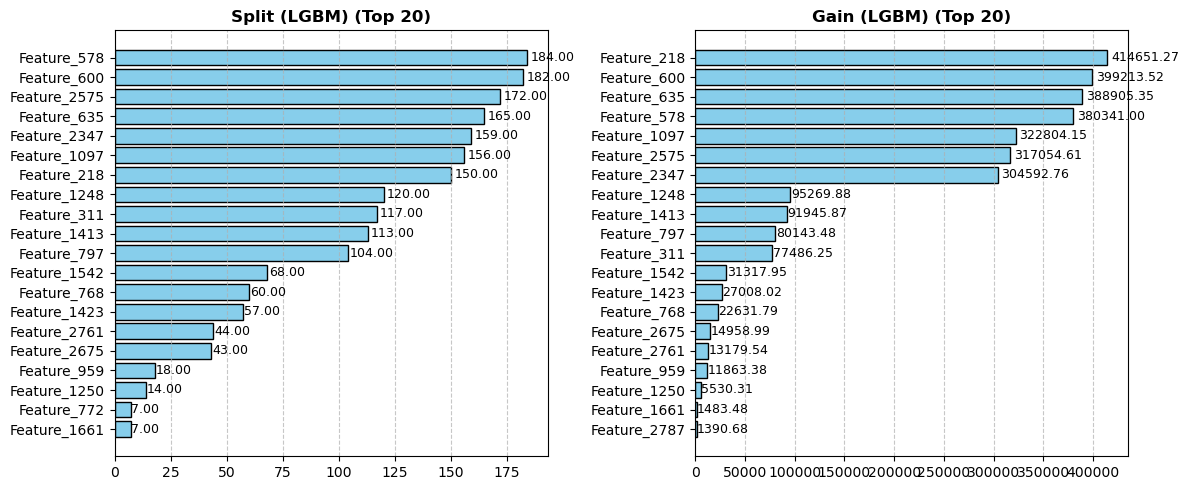

{'Split (LGBM)': {'Feature_578': 184,
  'Feature_600': 182,
  'Feature_2575': 172,
  'Feature_635': 165,
  'Feature_2347': 159,
  'Feature_1097': 156,
  'Feature_218': 150,
  'Feature_1248': 120,
  'Feature_311': 117,
  'Feature_1413': 113,
  'Feature_797': 104,
  'Feature_1542': 68,
  'Feature_768': 60,
  'Feature_1423': 57,
  'Feature_2761': 44,
  'Feature_2675': 43,
  'Feature_959': 18,
  'Feature_1250': 14,
  'Feature_772': 7,
  'Feature_1661': 7,
  'Feature_2612': 7,
  'Feature_2787': 7,
  'Feature_693': 6,
  'Feature_0': 6,
  'Feature_1565': 5,
  'Feature_2246': 5,
  'Feature_404': 5,
  'Feature_2374': 5,
  'Feature_1307': 5,
  'Feature_1656': 5,
  'Feature_2598': 5,
  'Feature_1528': 5,
  'Feature_644': 5,
  'Feature_1475': 5,
  'Feature_1054': 5,
  'Feature_323': 5,
  'Feature_188': 5,
  'Feature_1364': 5,
  'Feature_1369': 5,
  'Feature_2559': 5,
  'Feature_2191': 5,
  'Feature_2526': 5,
  'Feature_2522': 5,
  'Feature_2868': 5,
  'Feature_1401': 5,
  'Feature_2495': 5,
  'Fea

In [85]:

Importances = plot_model_importances(model, feature_names=X_train.columns, max_features=20)

Importances


In [86]:
# Importances.keys()

C = 1.0 # Adjust this constant to be more or less strict in filtering features based on standard deviation

for imp_type, imp_values in Importances.items():
    # Filter features based on standard deviation
    significant_features = imp_values
    significant_features = {k: v for k, v in significant_features.items() if v > np.mean(list(significant_features.values())) +C*np.std(list(significant_features.values()))}

    print(f"Testing {imp_type}:")
    # metrics = evaluate_feature_discovery(significant_features, true_linear_weights, true_interaction_weights)
    metrics = evaluate_feature_discovery(
        detected_features=significant_features,
        ground_truth=ground_truth,
        evaluated_features=None,
    )


Testing Split (LGBM):
        FEATURE DISCOVERY EVALUATION             
Overall Precision : 1.0000 (18/18)
Overall Recall    : 0.4500 (18/40)
Overall F1-Score  : 0.6207
False Positives   : []

---------------- Category Breakdown --------------

[LINEAR]
  True Features     : ['Feature_1097', 'Feature_1248', 'Feature_1413', 'Feature_1423', 'Feature_1542', 'Feature_218', 'Feature_2347', 'Feature_2575', 'Feature_2597', 'Feature_578', 'Feature_600', 'Feature_635', 'Feature_797']
  Detected          : ['Feature_1097', 'Feature_1248', 'Feature_1413', 'Feature_1423', 'Feature_1542', 'Feature_218', 'Feature_2347', 'Feature_2575', 'Feature_578', 'Feature_600', 'Feature_635', 'Feature_797']
  Missed            : ['Feature_2597']
  Recall            : 0.9231 (12/13)

[POLY]
  True Features     : ['Feature_2675', 'Feature_2761', 'Feature_768']
  Detected          : ['Feature_2675', 'Feature_2761', 'Feature_768']
  Missed            : []
  Recall            : 1.0000 (3/3)

[V_SHAPED]
  True Feature

In [87]:


# get a list of the union of the keys of true_linear_weights and true_interaction_weights
# all_keys = set(true_linear_weights.keys()) | set(true_interaction_weights.keys())
all_keys = (
    set(ground_truth["linear"].keys())
    | set(ground_truth["poly"].keys())
    | set(ground_truth["v_shaped"].keys())
    | {f for item in ground_truth["interactions"] for f in item["features"]}
)
all_visible_keys = {f for f in all_keys if not f.startswith("Hidden_")}
all_keys = all_visible_keys
all_keys

for imp_type, imp_values in Importances.items():
    print(f"Mean {imp_type} for true contributing features:", np.mean([imp_values.get(k, 0) for k in all_keys]))
    print(f"Mean {imp_type} for non-contributing features:", np.mean([imp_values.get(k, 0) for k in imp_values if k not in all_keys]))
    print(f"STD {imp_type} for all features:", np.std(list(imp_values.values())))

    # Get the importances for all keys
    importances_for_all_keys = {k: imp_values.get(k, 0) for k in all_keys}
    # Sort by importance
    sorted_importances = dict(sorted(importances_for_all_keys.items(), key=lambda item: item[1], reverse=True))
    print(f"{imp_type} for all contributing features (sorted):")
    print(sorted_importances)
    print("\n")
    print("----------------------------------------------------\n")





Mean Split (LGBM) for true contributing features: 48.825
Mean Split (LGBM) for non-contributing features: 1.2439189189189188
STD Split (LGBM) for all features: 9.337283539064716
Split (LGBM) for all contributing features (sorted):
{'Feature_578': 184, 'Feature_600': 182, 'Feature_2575': 172, 'Feature_635': 165, 'Feature_2347': 159, 'Feature_1097': 156, 'Feature_218': 150, 'Feature_1248': 120, 'Feature_311': 117, 'Feature_1413': 113, 'Feature_797': 104, 'Feature_1542': 68, 'Feature_768': 60, 'Feature_1423': 57, 'Feature_2761': 44, 'Feature_2675': 43, 'Feature_959': 18, 'Feature_1250': 14, 'Feature_1856': 3, 'Feature_1998': 3, 'Feature_173': 3, 'Feature_2382': 3, 'Feature_362': 3, 'Feature_2295': 2, 'Feature_680': 2, 'Feature_2412': 2, 'Feature_1515': 2, 'Feature_2367': 1, 'Feature_1260': 1, 'Feature_2496': 1, 'Feature_832': 1, 'Feature_2904': 0, 'Feature_458': 0, 'Feature_1384': 0, 'Feature_1689': 0, 'Feature_2881': 0, 'Feature_577': 0, 'Feature_2597': 0, 'Feature_1101': 0, 'Feature_114

### try to use SHAP to find the influencing inputs

In [88]:

# 5. Explainability (SHAP)
start_time = time.time()
shap_values = compute_shap_values(model, X_train, X_test)
end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")


Execution time: 2.9590189456939697 seconds


#### individual SHAP features ranking

Plotting SHAP analysis for top 5 features: ['Feature_218', 'Feature_635', 'Feature_600', 'Feature_578', 'Feature_1097']


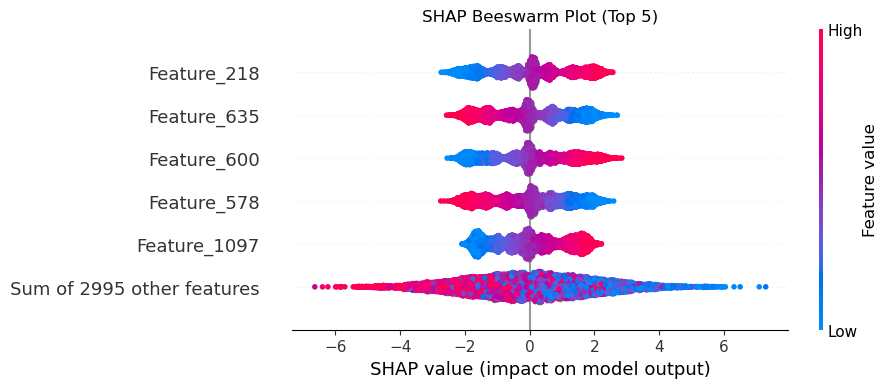

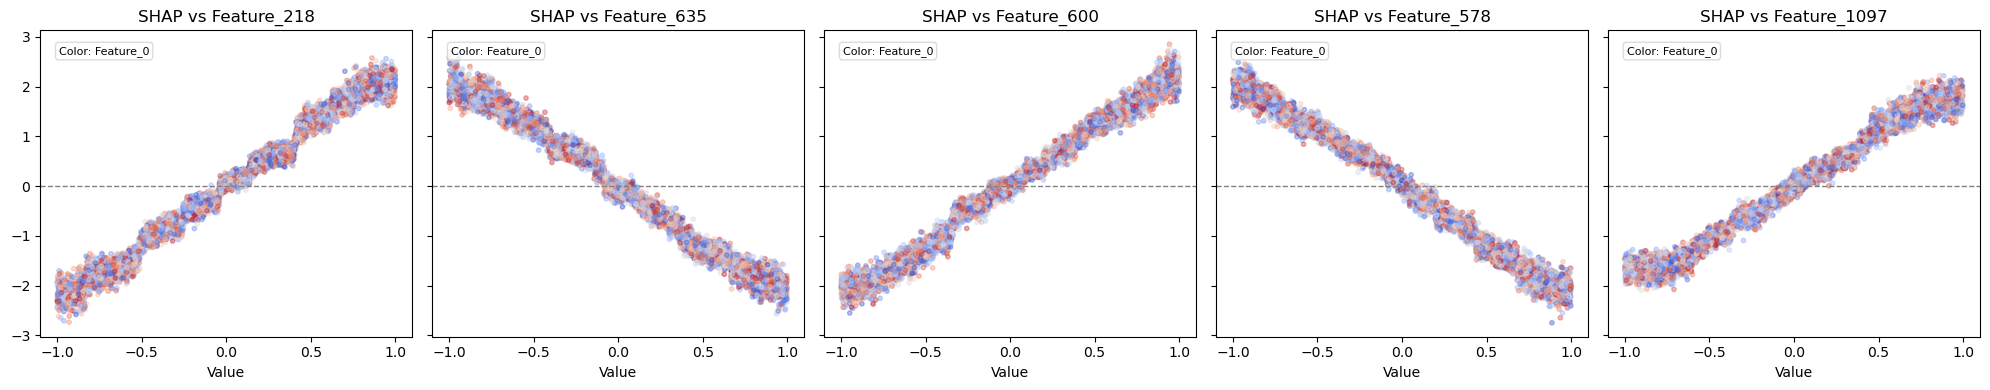

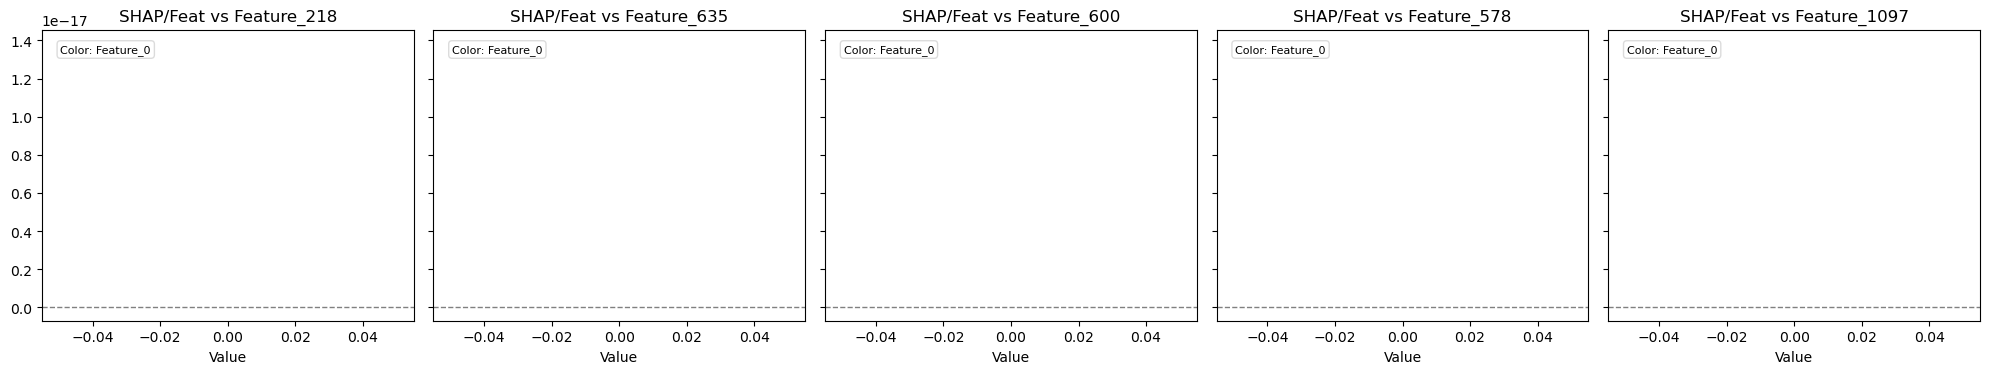

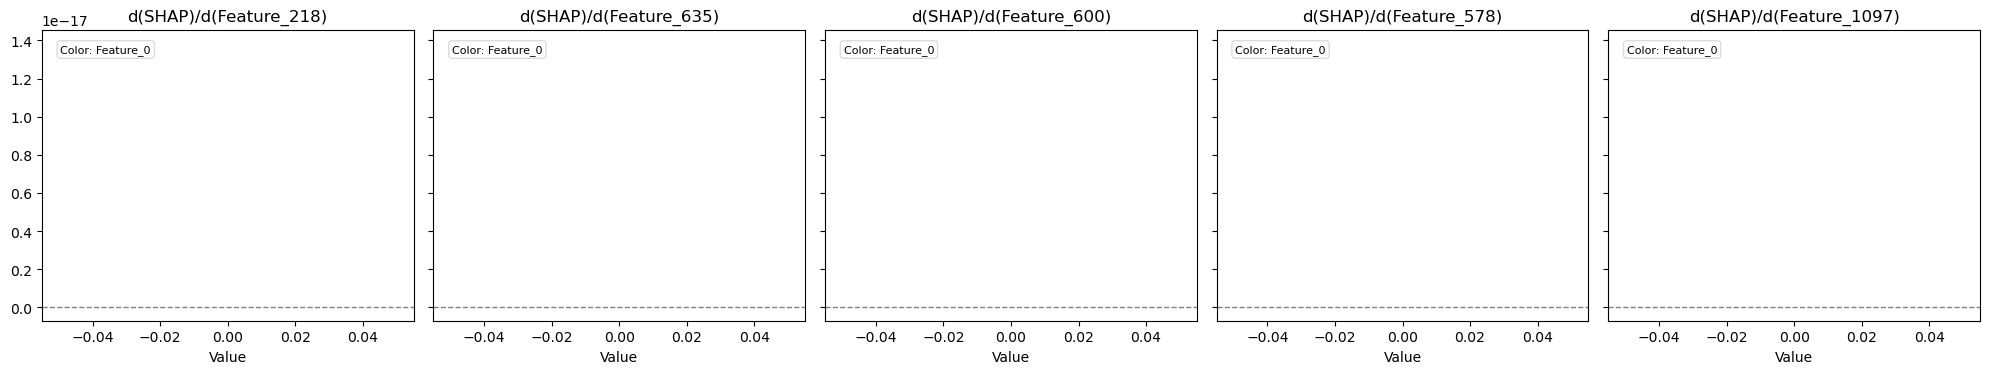

In [90]:

# 6. Visualization (SHAP)
plot_shap_analysis(shap_values, feature_names=X_train.columns)


#### SHAP summry

In [91]:

# 8. Summary (SHAP)
ranked_features = print_feature_importance(shap_values)

print("Ranked Features by SHAP Importance:", ranked_features)



--- SHAP Feature Importance Ranking ---
SHAP Global Importance Dictionary:
  Feature_218: 1.0783
  Feature_635: 1.0484
  Feature_600: 1.0477
  Feature_578: 1.0351
  Feature_1097: 0.9436
  Feature_2575: 0.9386
  Feature_2347: 0.9077
  Feature_1248: 0.4645
  Feature_1413: 0.4524
  Feature_797: 0.4253
  Feature_311: 0.4027
  Feature_1542: 0.2277
  Feature_1423: 0.2161
  Feature_768: 0.1911
  Feature_2675: 0.1487
  Feature_2761: 0.1255
  Feature_1250: 0.0363
  Feature_959: 0.0336
  Feature_772: 0.0212
  Feature_2956: 0.0172
  Feature_1661: 0.0163
  Feature_773: 0.0147
  Feature_1845: 0.0143
  Feature_2559: 0.0142
  Feature_1249: 0.0139
  Feature_2122: 0.0133
  Feature_1329: 0.0124
  Feature_1212: 0.0123
  Feature_2647: 0.0111
  Feature_2212: 0.0111
  Feature_2811: 0.0110
  Feature_2012: 0.0109
  Feature_644: 0.0109
  Feature_1900: 0.0108
  Feature_1401: 0.0106
  Feature_793: 0.0105
  Feature_2689: 0.0104
  Feature_0: 0.0104
  Feature_1739: 0.0100
  Feature_385: 0.0099
  Feature_1389: 0.00

#### test SHAP Importances results

In [92]:
C = 1.0 # Adjust this constant to be more or less strict in filtering features based on standard deviation

significant_features = ranked_features
# get only values above the mean
significant_features = {k: v for k, v in significant_features.items() if v > np.mean(list(significant_features.values())) +C*np.std(list(significant_features.values()))}
significant_features 

print("Testing SHAP importance:")
# metrics = evaluate_feature_discovery(significant_features, true_linear_weights, true_interaction_weights)
metrics = evaluate_feature_discovery(
    detected_features=significant_features,
    ground_truth=ground_truth,
    evaluated_features=None,
)



Testing SHAP importance:
        FEATURE DISCOVERY EVALUATION             
Overall Precision : 1.0000 (16/16)
Overall Recall    : 0.4000 (16/40)
Overall F1-Score  : 0.5714
False Positives   : []

---------------- Category Breakdown --------------

[LINEAR]
  True Features     : ['Feature_1097', 'Feature_1248', 'Feature_1413', 'Feature_1423', 'Feature_1542', 'Feature_218', 'Feature_2347', 'Feature_2575', 'Feature_2597', 'Feature_578', 'Feature_600', 'Feature_635', 'Feature_797']
  Detected          : ['Feature_1097', 'Feature_1248', 'Feature_1413', 'Feature_1423', 'Feature_1542', 'Feature_218', 'Feature_2347', 'Feature_2575', 'Feature_578', 'Feature_600', 'Feature_635', 'Feature_797']
  Missed            : ['Feature_2597']
  Recall            : 0.9231 (12/13)

[POLY]
  True Features     : ['Feature_2675', 'Feature_2761', 'Feature_768']
  Detected          : ['Feature_2675', 'Feature_2761', 'Feature_768']
  Missed            : []
  Recall            : 1.0000 (3/3)

[V_SHAPED]
  True Feat

In [93]:


# get a list of the union of the keys of true_linear_weights and true_interaction_weights
# all_keys = set(true_linear_weights.keys()) | set(true_interaction_weights.keys())
all_keys = (
    set(ground_truth["linear"].keys())
    | set(ground_truth["poly"].keys())
    | set(ground_truth["v_shaped"].keys())
    | {f for item in ground_truth["interactions"] for f in item["features"]}
)
all_visible_keys = {f for f in all_keys if not f.startswith("Hidden_")}
all_keys = all_visible_keys
all_keys

print("Mean MODEL SHAP importance for true contributing features:", np.mean([ranked_features.get(k, 0) for k in all_keys]))
print("Mean MODEL SHAP importance for non-contributing features:", np.mean([ranked_features.get(k, 0) for k in ranked_features if k not in all_keys]))

print("STD MODEL SHAP importance for all features:", np.std([ranked_features.get(k, 0) for k in ranked_features]))

# Get the SHAP importances for all keys
shap_importances_for_all_keys = {k: ranked_features.get(k, 0) for k in all_keys}
# Sort by importance
sorted_shap_importances = dict(sorted(shap_importances_for_all_keys.items(), key=lambda item: item[1], reverse=True))
print("MODEL SHAP importance for all contributing features (sorted):")
sorted_shap_importances



Mean MODEL SHAP importance for true contributing features: 0.2438109856264885
Mean MODEL SHAP importance for non-contributing features: 0.0013246458752594423
STD MODEL SHAP importance for all features: 0.051376022430842945
MODEL SHAP importance for all contributing features (sorted):


{'Feature_218': 1.0783439667953756,
 'Feature_635': 1.0484003000961097,
 'Feature_600': 1.047730433420223,
 'Feature_578': 1.03507733552004,
 'Feature_1097': 0.9435536990835095,
 'Feature_2575': 0.9385686266323535,
 'Feature_2347': 0.9076583102441206,
 'Feature_1248': 0.46449562974700365,
 'Feature_1413': 0.45243132225843247,
 'Feature_797': 0.42534878438430235,
 'Feature_311': 0.4027293222787336,
 'Feature_1542': 0.22770910024876698,
 'Feature_1423': 0.21605026402585212,
 'Feature_768': 0.19108671093295046,
 'Feature_2675': 0.14868736489080173,
 'Feature_2761': 0.12549747898955432,
 'Feature_1250': 0.03625162332170347,
 'Feature_959': 0.03357108191244436,
 'Feature_832': 0.005783966074057062,
 'Feature_2382': 0.005008537932765183,
 'Feature_1515': 0.004088982941506579,
 'Feature_1998': 0.0030769322435823627,
 'Feature_2412': 0.0020070808191049315,
 'Feature_1856': 0.0018601427832305878,
 'Feature_680': 0.0016759052918828925,
 'Feature_173': 0.0014130597293420535,
 'Feature_2295': 0.00